## 
    Alaska
    Time period	: 1941 - 2023
    
    location:   s(glost,k=5)  
    
    scale	    s(glost,k=k) with k=5,2,1  COMPARISONS
    shape       1



In [44]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
from xhistogram.xarray import histogram
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
from copy import copy
from matplotlib import cm

In [45]:
import rpy2
from rpy2.robjects.packages import importr, data
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro
from rpy2.robjects import globalenv

extRemes = importr("extRemes")
evgam = importr("evgam")
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [46]:
%config InlineBackend.figure_format = 'retina'
plt.style.use("cma.mplstyle")

In [47]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

# READ Return_Level files CONUS

In [48]:
yearb=1941
yeare=2023
itest='loc_sck1_loess'
domain='Alaska'

lon_min=185;lon_max=235
lat_min=53;lat_max=75
### k=5 
itest='loc_sc_loess'
file=f'../AFI/{domain}_afi_return.evgam.{yearb}_{yeare}_{itest}.nc'
ds=xr.open_mfdataset(file)
Rlocation5   = ds['location']
Rscale5      = ds['scale']
Rshape5      = ds['shape']
Rrl1005      = ds['rl100']
locpvalue5 = ds['locationpvalue']
scapvalue5 = ds['scalepvalue']
shapvalue5 = ds['shapepvalue']
NSlocpvalue5 = ds['NSlocationpvalue']
NSscapvalue5 = ds['NSscalepvalue']
ann_glost = ds['glost']

### k=2 
itest='loc_sck2_loess'
file=f'../AFI/{domain}_afi_return.evgam.{yearb}_{yeare}_{itest}.nc'
ds=xr.open_mfdataset(file)
Rlocation2   = ds['location']
Rscale2      = ds['scale']
Rshape2      = ds['shape']
Rrl1002      = ds['rl100']
locpvalue2 = ds['locationpvalue']
scapvalue2 = ds['scalepvalue']
shapvalue2 = ds['shapepvalue']
NSlocpvalue2 = ds['NSlocationpvalue']
NSscapvalue2 = ds['NSscalepvalue']

### k=1 
itest='loc_sck1_loess'
file=f'../AFI/{domain}_afi_return.evgam.{yearb}_{yeare}_{itest}.nc'
ds=xr.open_mfdataset(file)
Rlocation1   = ds['location']
Rscale1      = ds['scale']
Rshape1      = ds['shape']
Rrl1001      = ds['rl100']
locpvalue1 = ds['locationpvalue']
scapvalue1 = ds['scalepvalue']
shapvalue1 = ds['shapepvalue']
NSlocpvalue1 = ds['NSlocationpvalue']
NSscapvalue1 = ds['NSscalepvalue']

#### Read AFI data  
#### Needed for point analysis
files=[f'../AFI/AFIT/AFI_ERA5_{iyear}.nc' for iyear in range(yearb,yeare+1)]

dsa=xr.open_mfdataset(files)
dsa=dsa.sortby('lat')
dsa=dsa.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
dsa['AFI']=dsa['AFI']*5/9.
dsa['time']=np.arange(yearb,yeare+1,1)
dsa = dsa.merge({'glost':ann_glost})

units='degree-days (°C)'
# parameters for smoothness 
%R fmla_gev5 <- list(AFI ~ s(glost,k=5) , ~ s(glost,k=5) , ~ 1)
%R fmla_gev2 <- list(AFI ~ s(glost,k=5) , ~ s(glost,k=2) , ~ 1)
%R fmla_gev1 <- list(AFI ~ s(glost,k=5) , ~ s(glost,k=1) , ~ 1)
spval = -99999
itest=f'Comparison_sck_{yearb}_{yeare}_{domain}'

The 100-year return level is expressed in degree-days (C).

In [49]:
cmap200=copy(cm.turbo)
cmap200.set_under('darkgrey', 1.0)
#
cmapBR=copy(cmaps.ncl_default)
cmapBR.set_under('darkgrey', 1.0)
cmapBR_ng=copy(cmaps.ncl_default)

#
cmapBR_r=copy(cmaps.ncl_default_r)
cmapBR_rng=copy(cmaps.ncl_default_r)
cmapBR_r.set_under('darkgrey', 1.0)
#
proj=ccrs.PlateCarree()

# Plot location

<>:53: SyntaxWarning: invalid escape sequence '\d'
<>:56: SyntaxWarning: invalid escape sequence '\d'
<>:53: SyntaxWarning: invalid escape sequence '\d'
<>:56: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/1946851762.py:53: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/1946851762.py:56: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/1946851762.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Purples',len(clevsa)+5)
/v

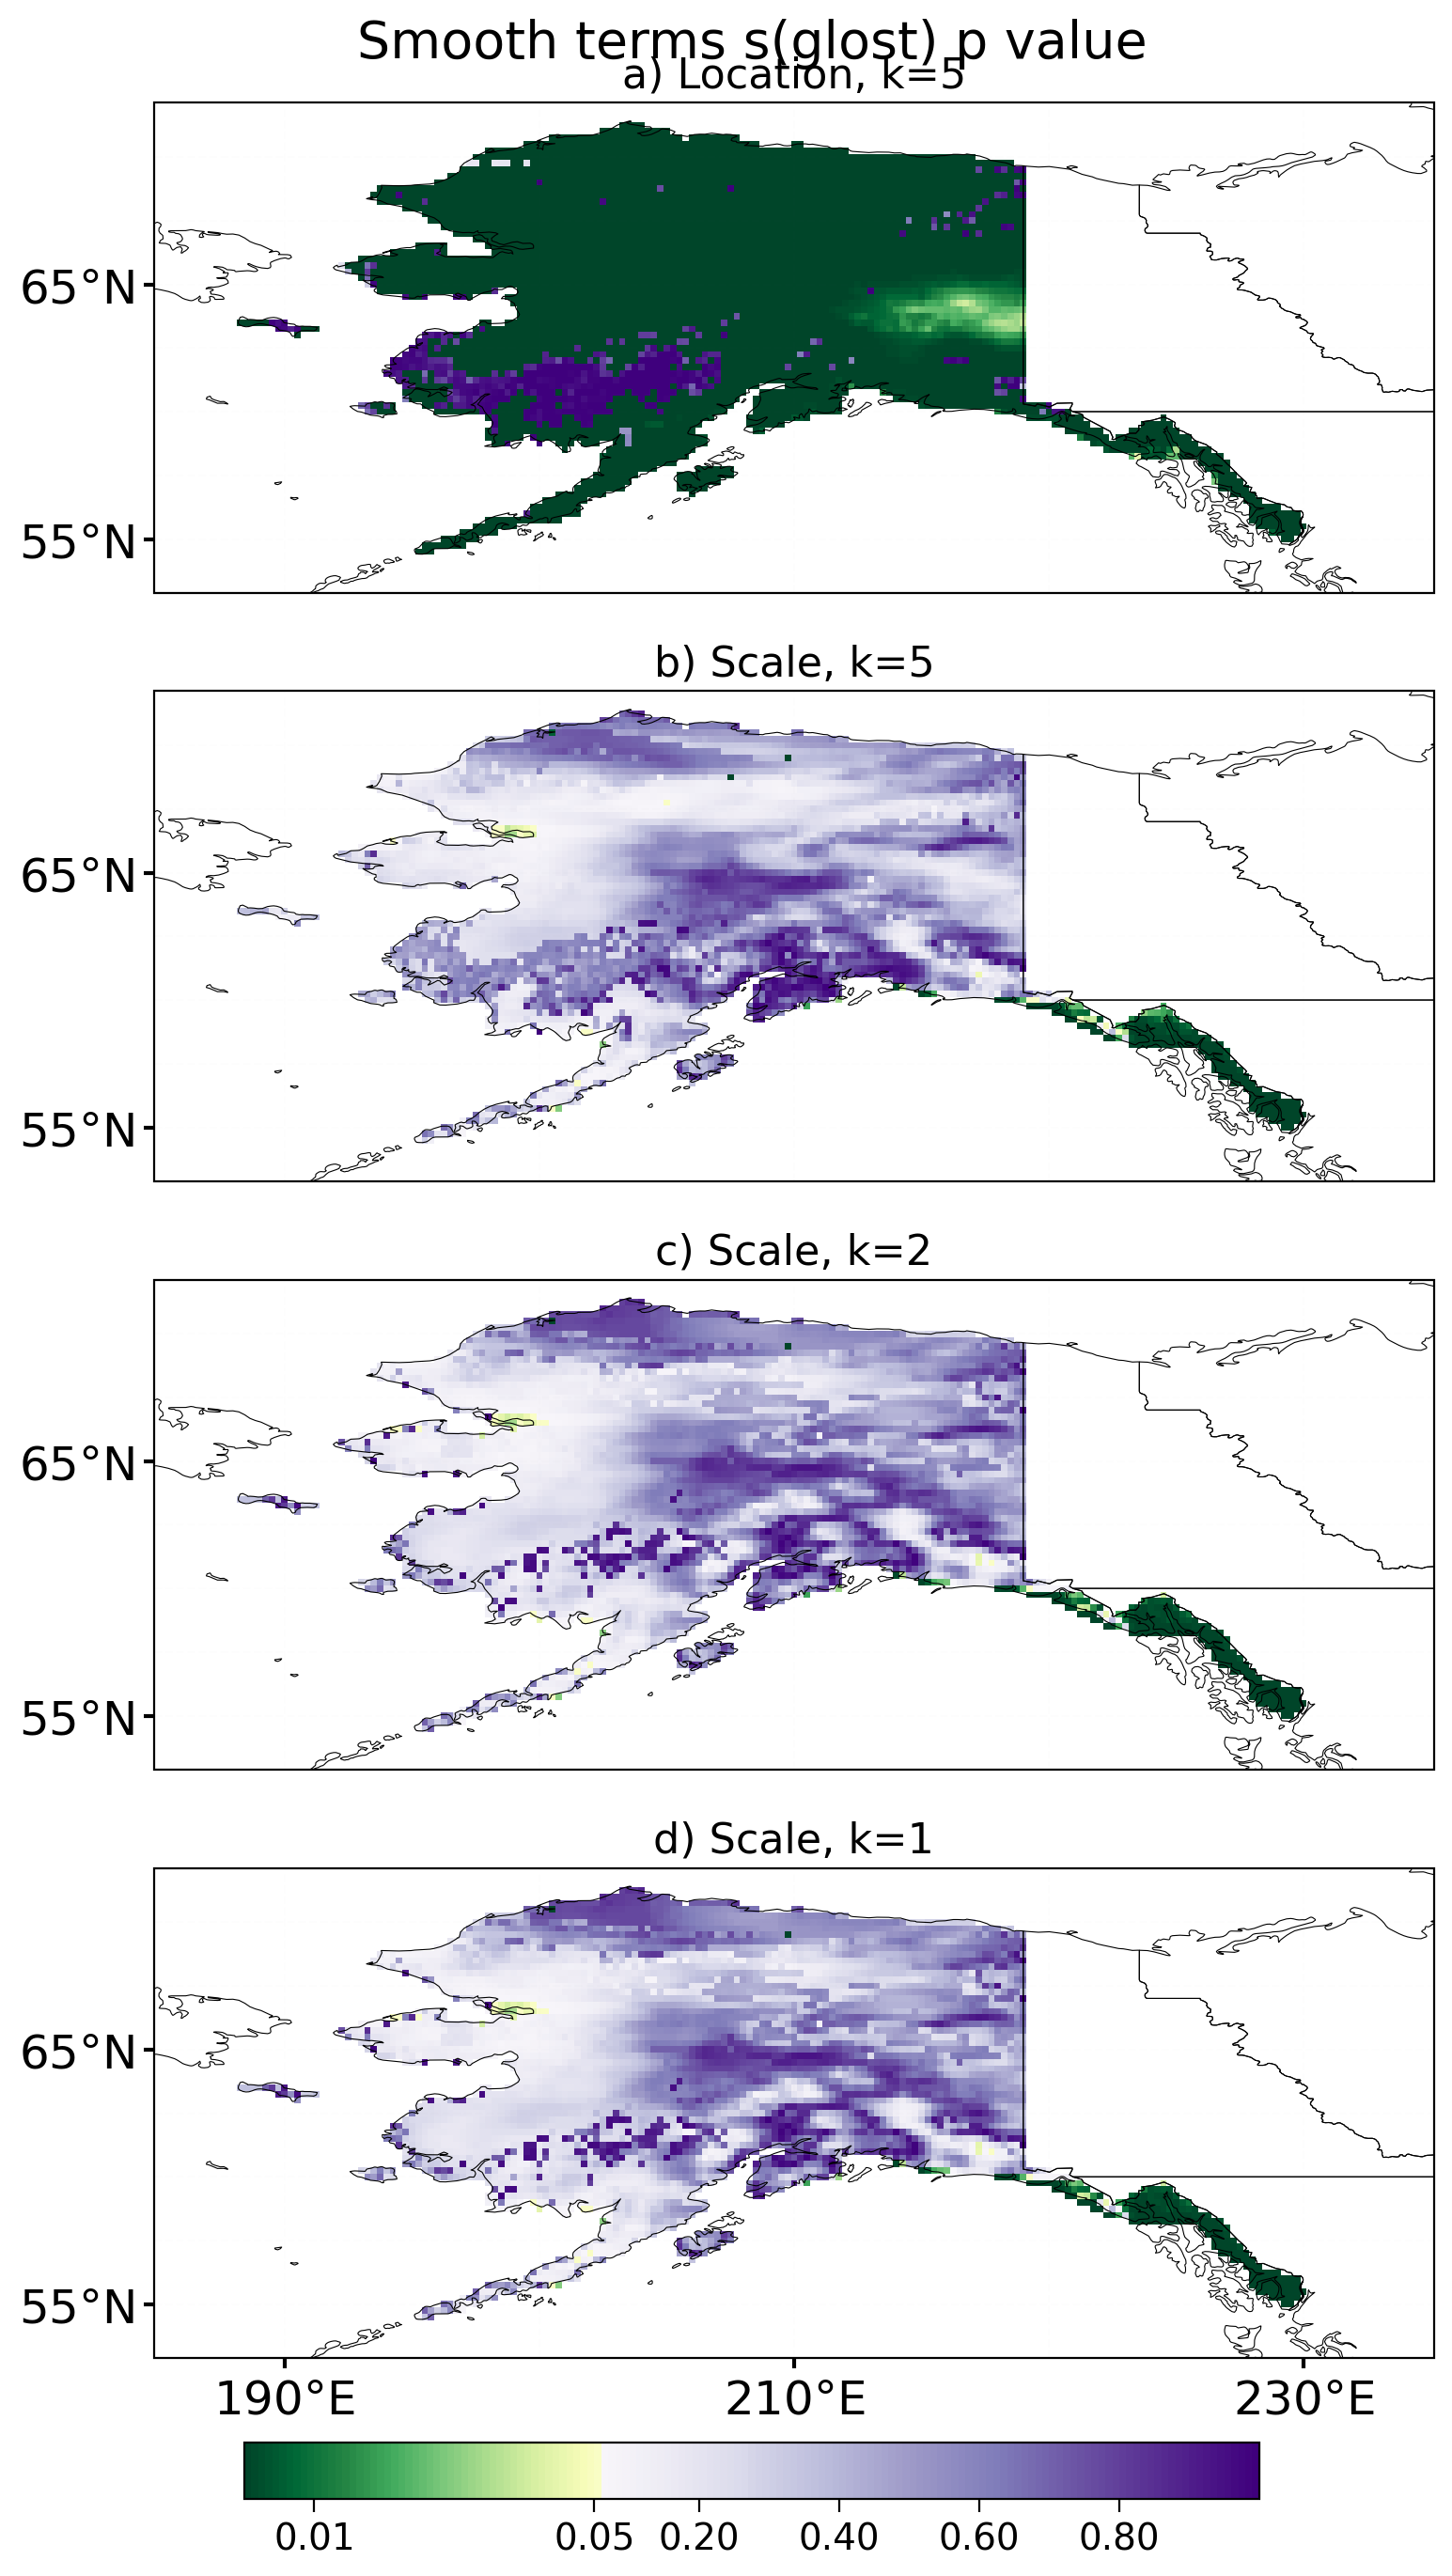

In [50]:
## Build colorbar
clevsa=np.arange(0.06,1.01,0.01)
clevsb=np.arange(0,0.051,0.001)
clevs=np.concatenate((clevsb,clevsa))
cmap = cm.get_cmap('Purples',len(clevsa)+5)
cmaplist = [cmap(i) for i in range(5,cmap.N)]
cmap2 = cm.get_cmap('YlGn_r', len(clevsb)+5)
cmaplist2 = [cmap2(i) for i in range(0,cmap2.N-5)]

my_cmap = colors.LinearSegmentedColormap.from_list('Custom cmap',\
                cmaplist2+cmaplist, len(cmaplist2)+len(cmaplist))

my_cmap.set_under('darkgrey', 1.0)

##########
##########

fig, ax = plt.subplots(nrows=4,ncols=1,figsize=(9,15),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15,top=0.95, left=0.1,right=0.95,hspace=0.2)

shrink=0.55
#
#  Location
#

my_cmap.set_under('darkgrey', 1.0)

cc=NSlocpvalue5.plot(ax=ax[0],cmap=my_cmap,levels=clevs,add_colorbar=False)
ax[0].set_title('a) Location, k=5',fontsize=16)
NSscapvalue5.plot(ax=ax[1],cmap=my_cmap,levels=clevs,add_colorbar=False)
ax[1].set_title('b) Scale, k=5',fontsize=16)
NSscapvalue2.plot(ax=ax[2],cmap=my_cmap,levels=clevs,add_colorbar=False)
ax[2].set_title('c) Scale, k=2',fontsize=16)
NSscapvalue1.plot(ax=ax[3],cmap=my_cmap,levels=clevs,add_colorbar=False)
ax[3].set_title('d) Scale, k=1',fontsize=16)
ax_cbar = fig.add_axes([0.2, 0.1, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar, ticks=[0.01,0.05,0.2,0.4,0.6,0.8],shrink=0.8,location='bottom',orientation='horizontal')
cbar.set_label(label=f'',fontsize=14)
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=14)
####
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')

  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == len(ax)-1: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('') 

fig.suptitle('Smooth terms s(glost) p value',fontsize=20)    
outfile=f'PLOTS/GEV_glost_pvalue_NS{itest}.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

Map of p-value of the smooth terms for the a) location (k=5), b) scale (k=5), c) scale (k=2), and scale (k=1) parameters. In grey, not enough AFI values > 0.

<>:44: SyntaxWarning: invalid escape sequence '\d'
<>:47: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\d'
<>:47: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/2997041994.py:44: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/2997041994.py:47: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


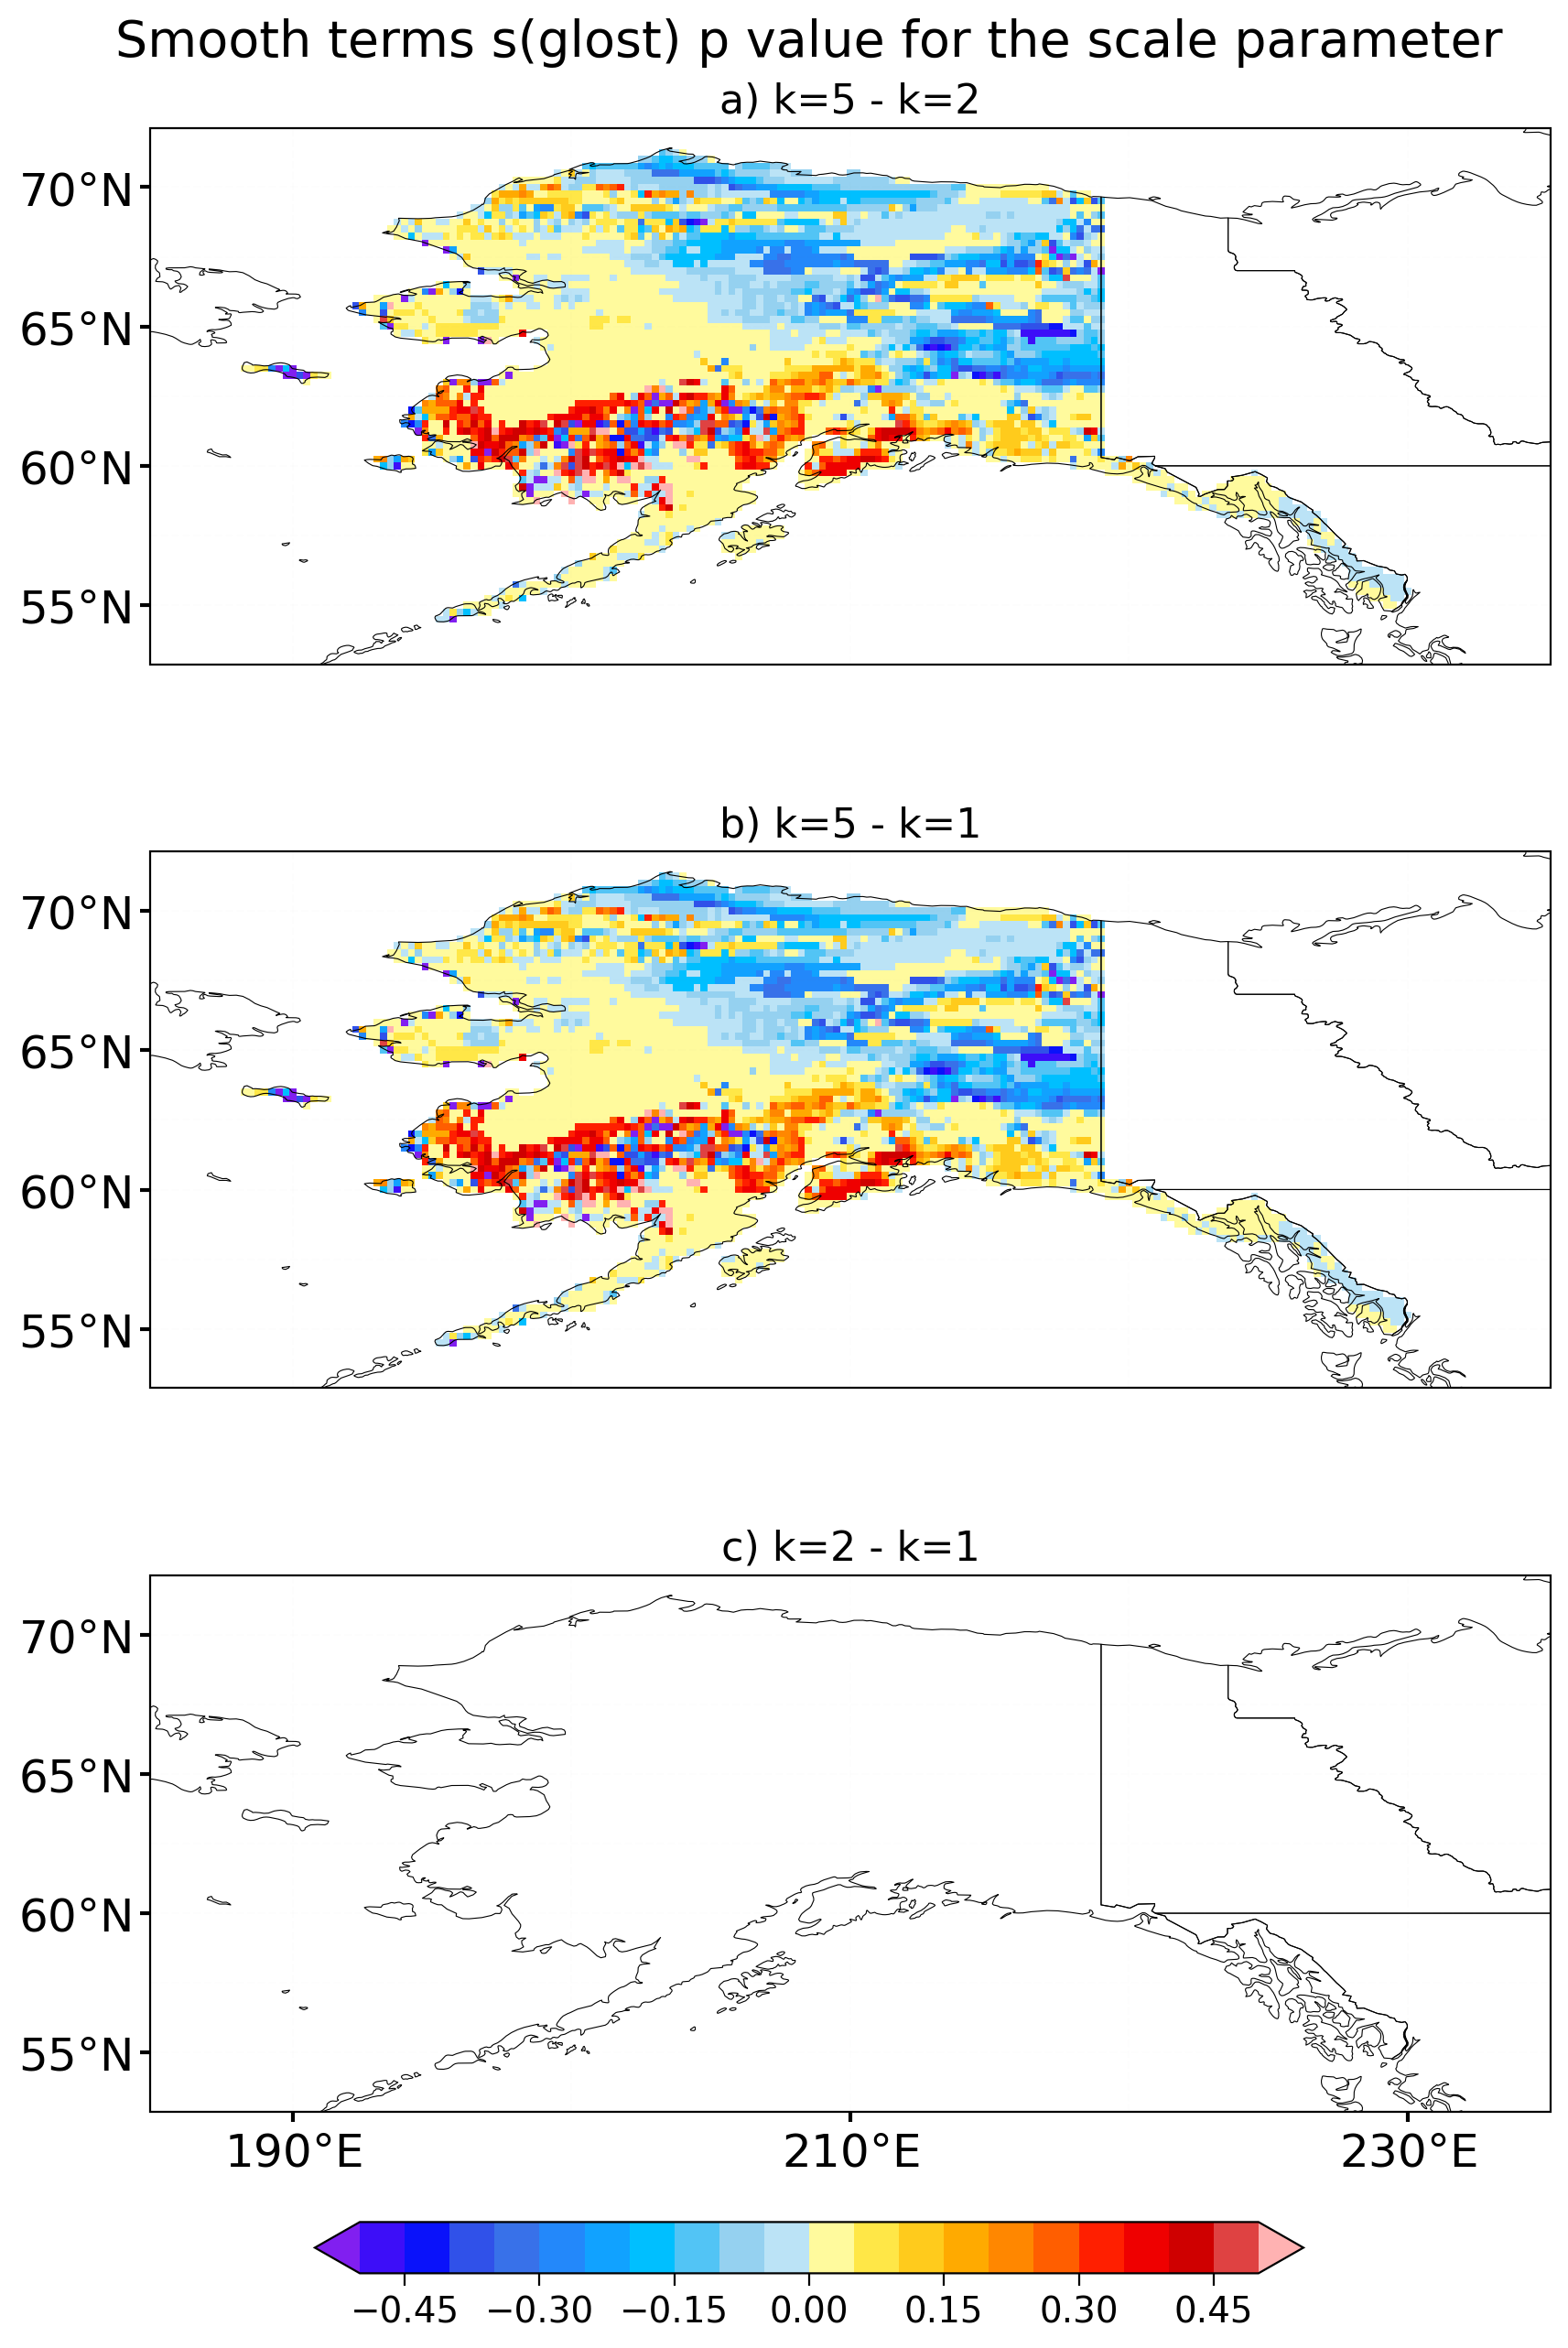

In [51]:
fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(9,14),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15,top=0.95, left=0.1,right=0.95,hspace=0.2)

shrink=0.55
#
#  Location
#

my_cmap.set_under('darkgrey', 1.0)
clevs=np.arange(-0.5,0.55,0.05)

data = NSscapvalue5-NSscapvalue2
data = data.where(data!=0.)
cc=data.plot(ax=ax[0],cmap=cmapBR_ng,levels=clevs,add_colorbar=False)
ax[0].set_title('a) k=5 - k=2',fontsize=16)

data = NSscapvalue5-NSscapvalue1
data = data.where(data!=0.)
data.plot(ax=ax[1],cmap=cmapBR_ng,levels=clevs,add_colorbar=False)
ax[1].set_title('b) k=5 - k=1',fontsize=16)

data = NSscapvalue2-NSscapvalue1
data = data.where(data!=0.)
data.plot(ax=ax[2],cmap=cmapBR_ng,levels=clevs,add_colorbar=False)
ax[2].set_title('c) k=2 - k=1',fontsize=16)

ax_cbar = fig.add_axes([0.2, 0.1, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.8,location='bottom',orientation='horizontal')
cbar.set_label(label=f'',fontsize=14)
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=14)
####
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')

  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == len(ax)-1: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('') 

fig.suptitle('Smooth terms s(glost) p value for the scale parameter',fontsize=20)    
outfile=f'PLOTS/GEV_glost_pvalue_NS{itest}.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

Map of difference of p-value of the scale smooth term a) k=5 - k=2, b) k=5 -k=1 , and c) k=2 - k=1. Masked when there is no difference. 

<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/2646465284.py:36: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/2646465284.py:39: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


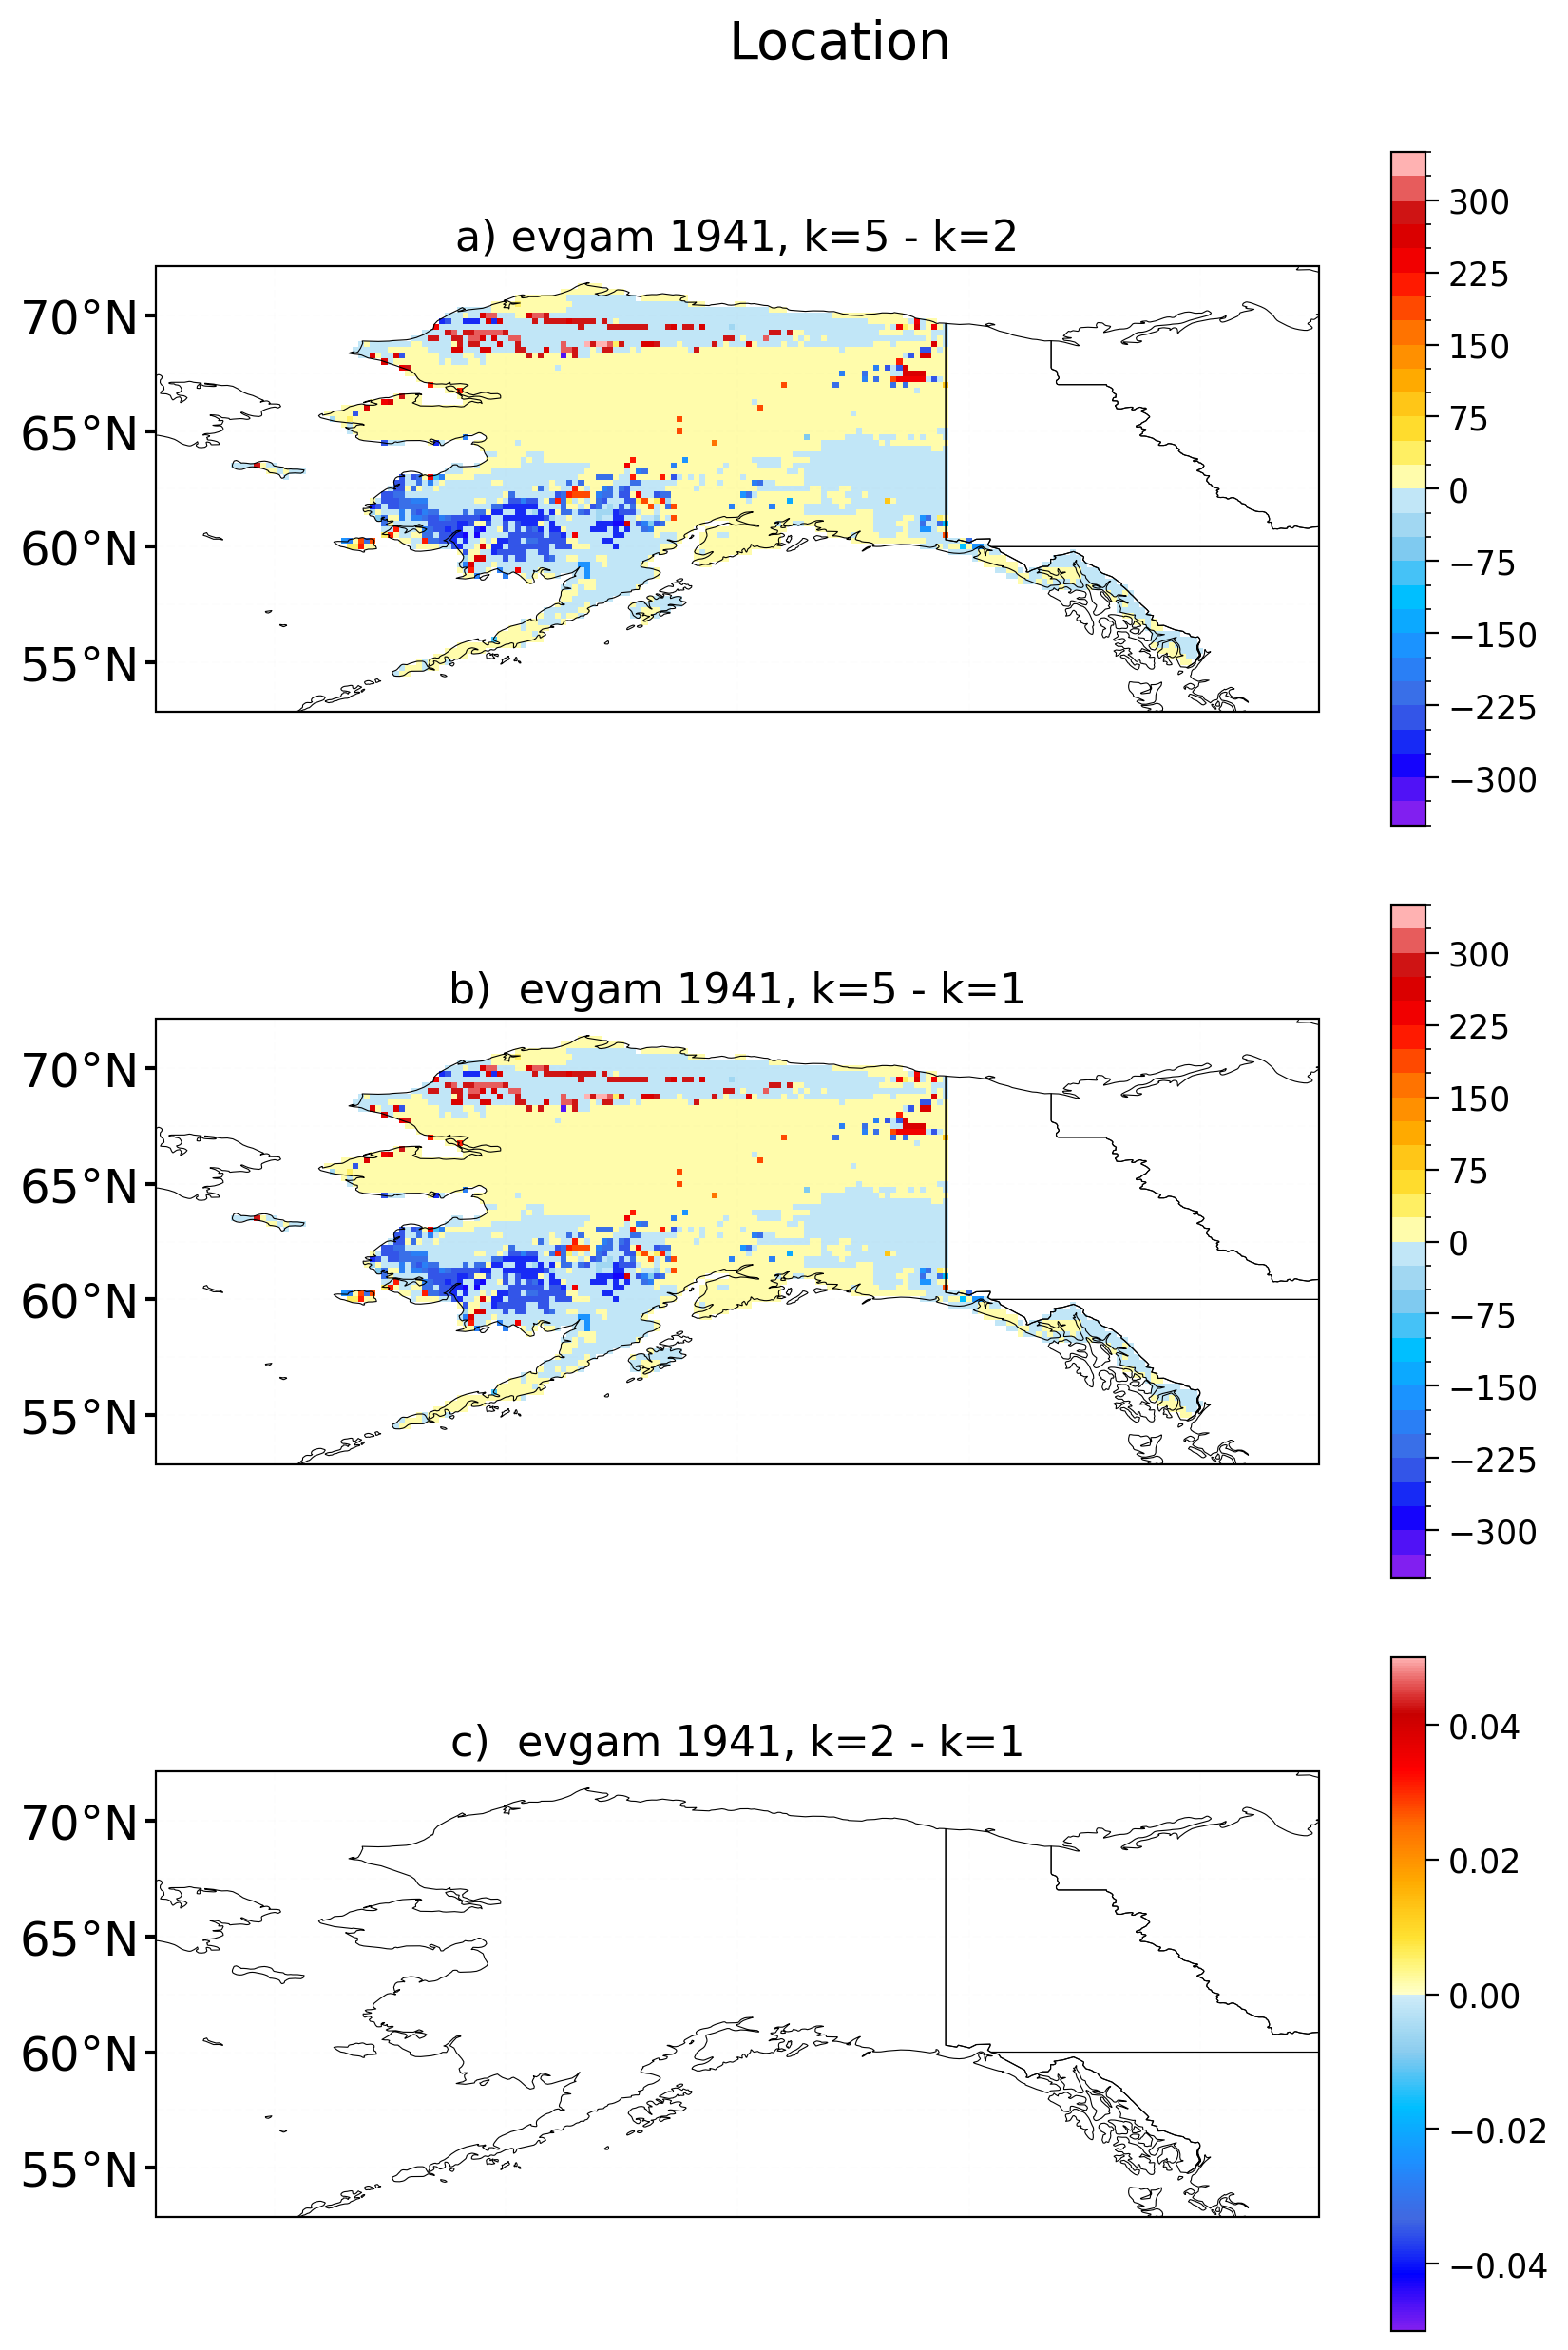

In [52]:

fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  Location
#
clevs = np.arange(-350,375,25)
data=Rlocation5.sel(time=yearb) - Rlocation2.sel(time=yearb)
data=data.where(data!=0.)
data.plot(ax=ax[0],cmap=cmapBR_ng,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title(f'a) evgam {yearb}, k=5 - k=2',fontsize=16)

data=Rlocation5.sel(time=yearb) - Rlocation1.sel(time=yearb)
data=data.where(data!=0.)
data.plot(ax=ax[1],cmap=cmapBR_ng,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'b)  evgam {yearb}, k=5 - k=1',fontsize=16)

data=Rlocation2.sel(time=yearb) - Rlocation1.sel(time=yearb)
data=data.where(data!=0.)
data.plot(ax=ax[2],cmap=cmapBR_ng,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'c)  evgam {yearb}, k=2 - k=1',fontsize=16)

####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')

  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('Location',fontsize=20)    
outfile=f'PLOTS/GEV_location_{yearb}_NS{itest}.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

Map of difference of location parameters from EVGAM with scale smoothing a) k=5 - k=2, b) k=5 -k=1 , and c) k=2 - k=1. Masked when there is no difference. 

<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/755485522.py:36: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/755485522.py:39: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


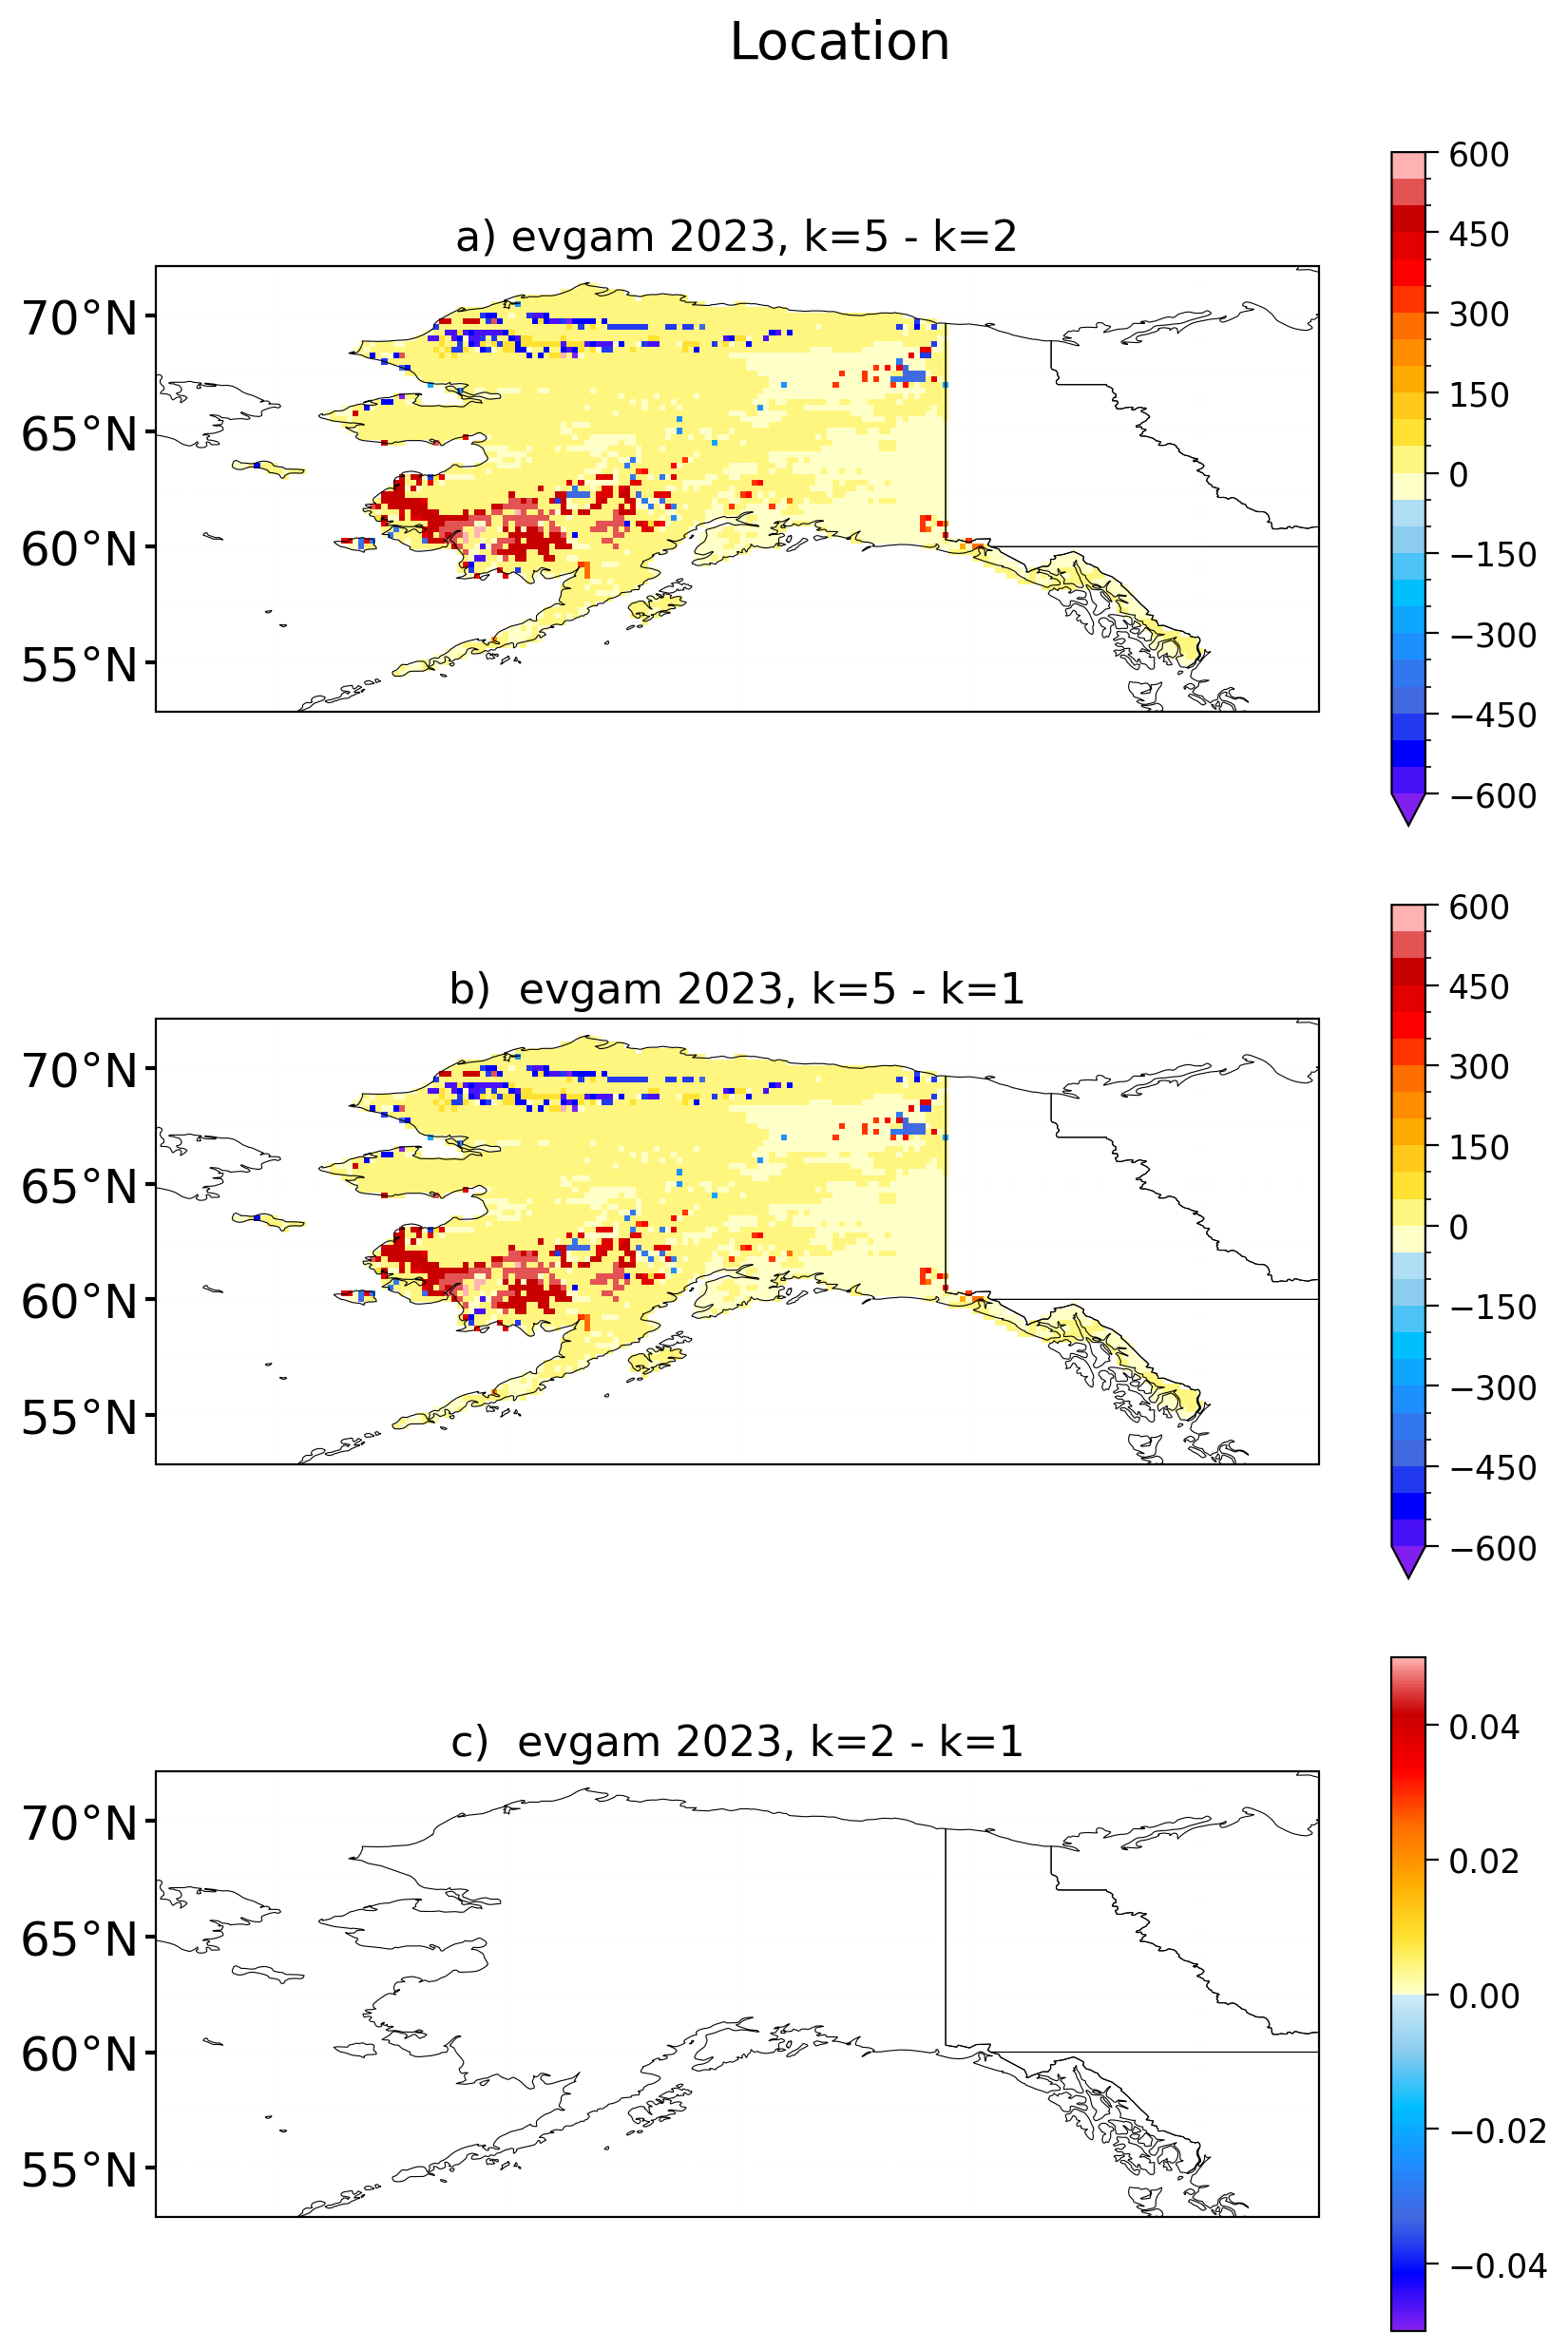

In [53]:

fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  Location
#
clevs = np.arange(-600,650,50)
data=Rlocation5.sel(time=yeare) - Rlocation2.sel(time=yeare)
data=data.where(data!=0.)
data.plot(ax=ax[0],cmap=cmapBR_ng,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title(f'a) evgam {yeare}, k=5 - k=2',fontsize=16)

data=Rlocation5.sel(time=yeare) - Rlocation1.sel(time=yeare)
data=data.where(data!=0.)
data.plot(ax=ax[1],cmap=cmapBR_ng,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'b)  evgam {yeare}, k=5 - k=1',fontsize=16)

data=Rlocation2.sel(time=yeare) - Rlocation1.sel(time=yeare)
data=data.where(data!=0.)
data.plot(ax=ax[2],cmap=cmapBR_ng,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'c)  evgam {yeare}, k=2 - k=1',fontsize=16)

####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')

  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('Location',fontsize=20)    
outfile=f'PLOTS/GEV_location_{yeare}_NS{itest}.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')


Map of difference of location parameters from EVGAM with scale smoothing a) k=5 - k=2, b) k=5 -k=1 , and c) k=2 - k=1. Masked when there is no difference. 

# Plot Scale

<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/1482511865.py:36: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/1482511865.py:39: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


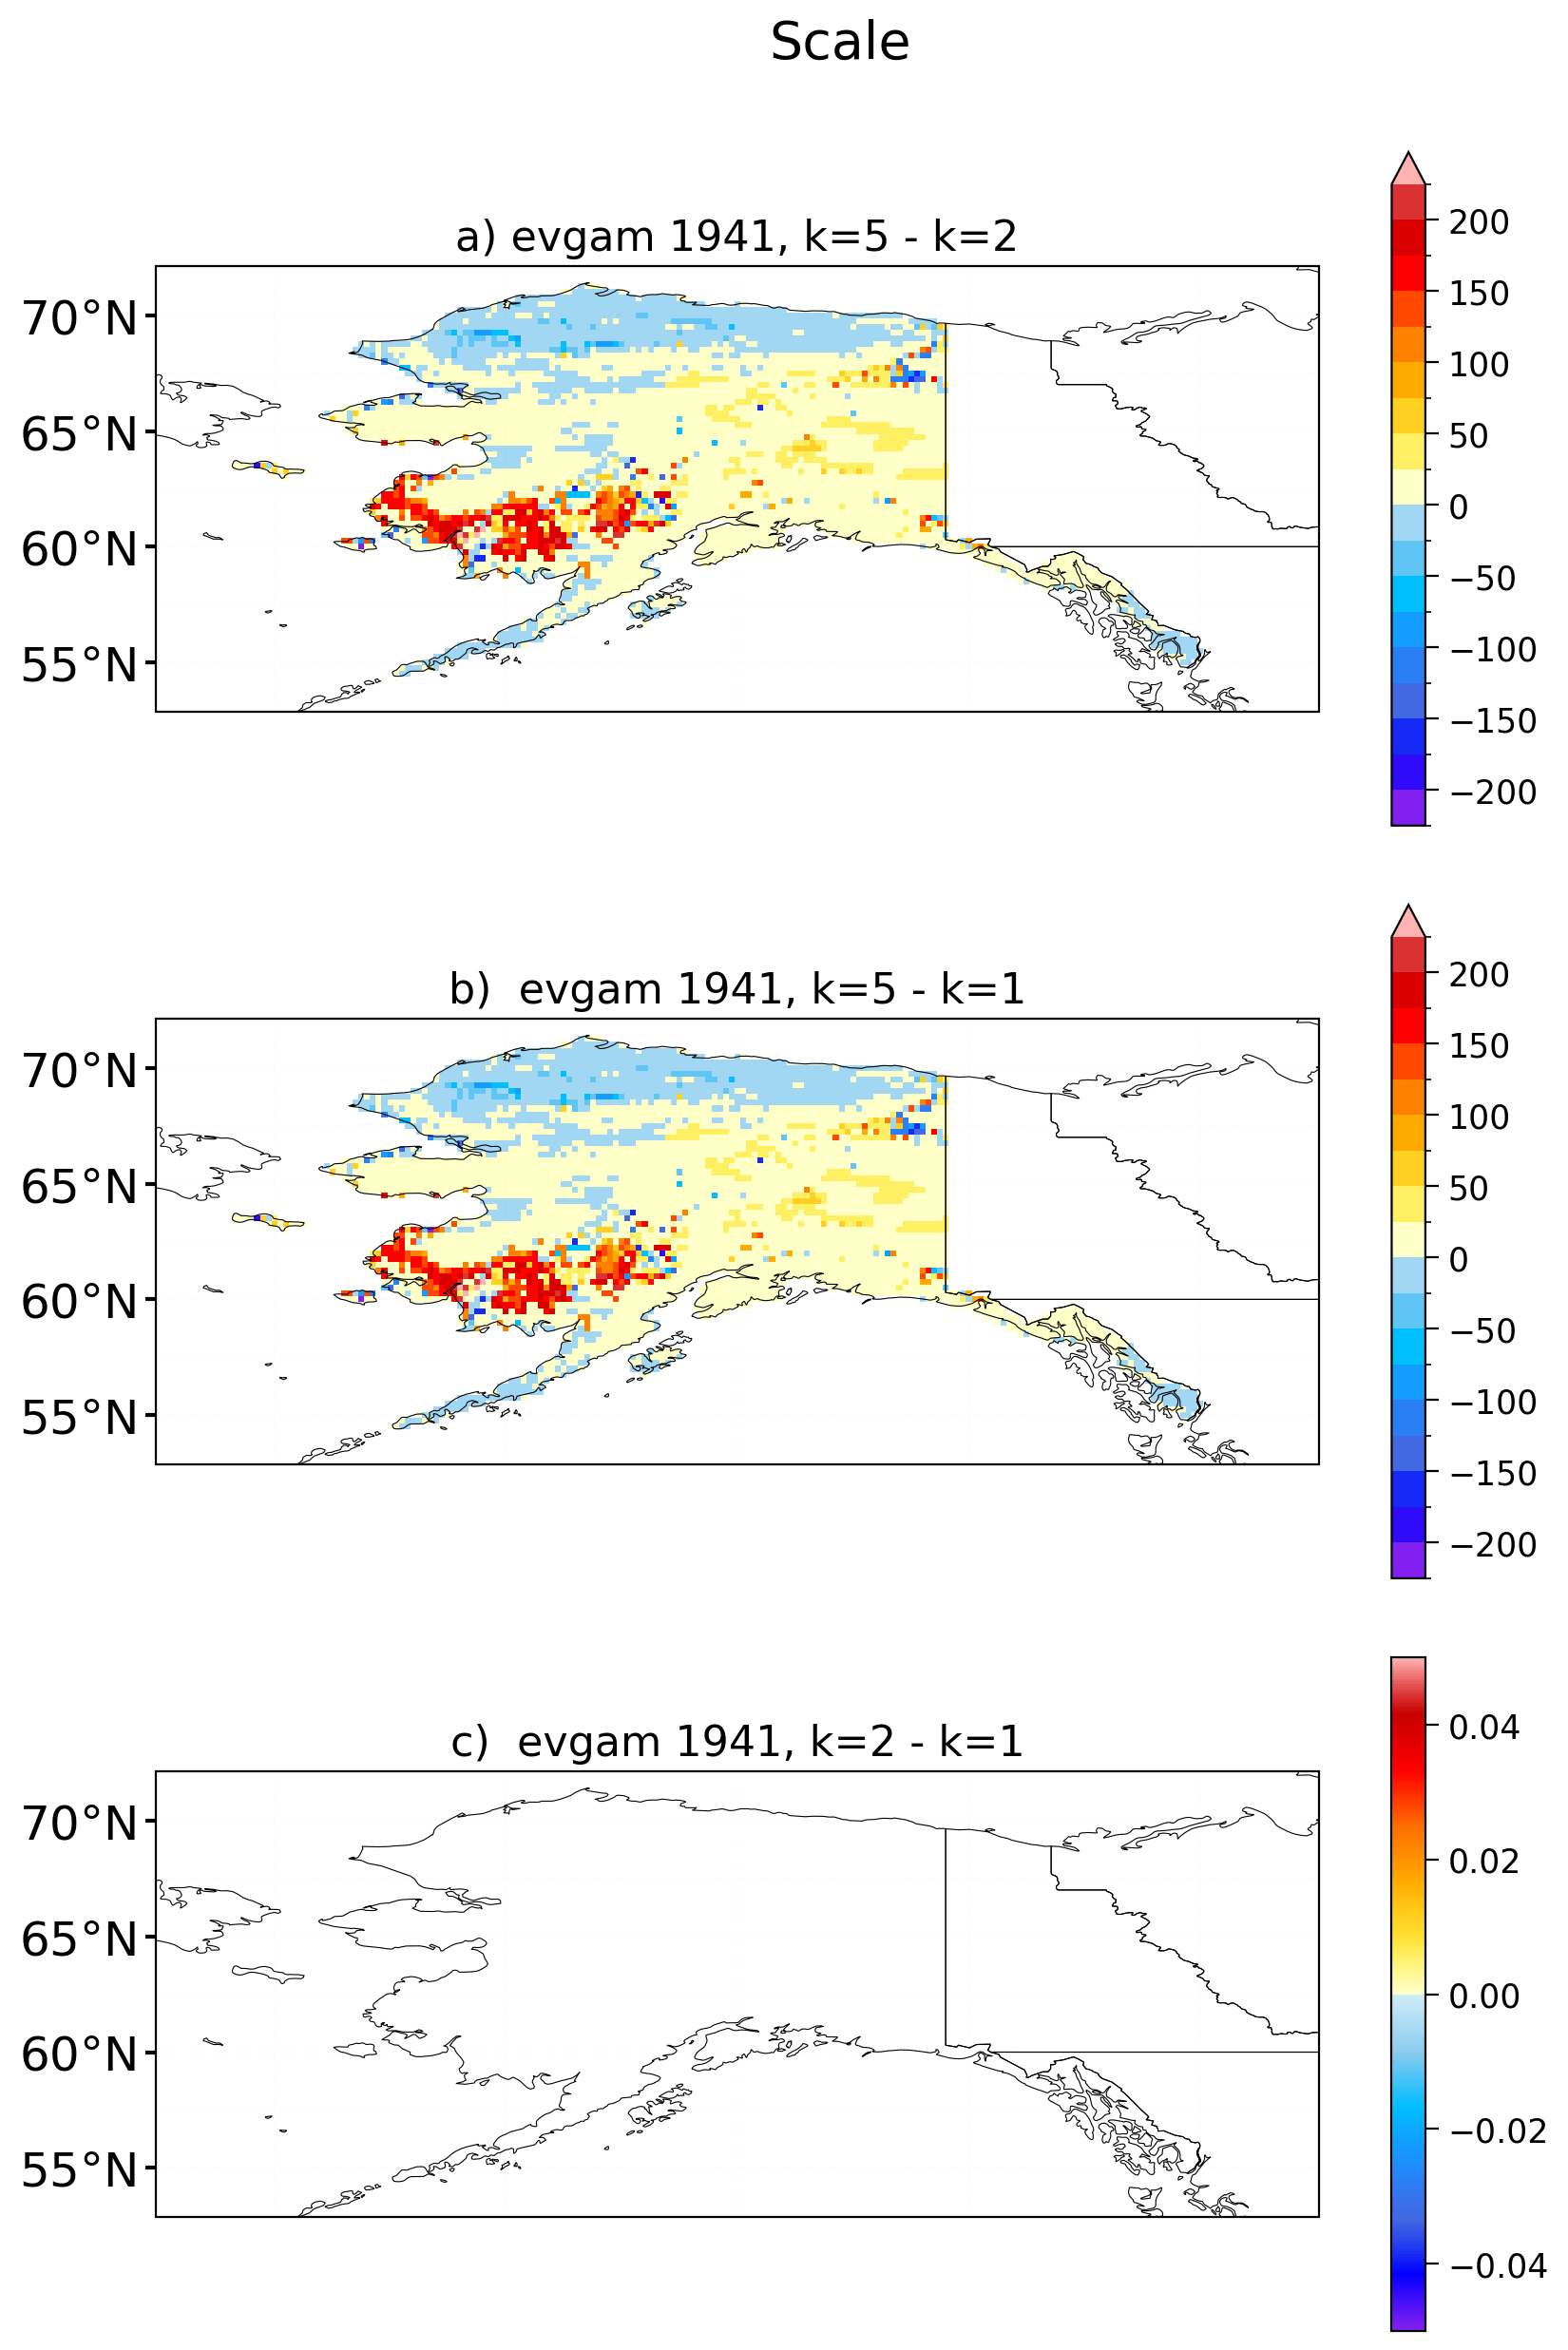

In [54]:
fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  Scale
#
clevs = np.arange(-225,250,25)
data=Rscale5.sel(time=yearb) - Rscale2.sel(time=yearb)
data=data.where(data!=0.)
data.plot(ax=ax[0],cmap=cmapBR_ng,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title(f'a) evgam {yearb}, k=5 - k=2',fontsize=16)

data=Rscale5.sel(time=yearb) - Rscale1.sel(time=yearb)
data=data.where(data!=0.)
data.plot(ax=ax[1],cmap=cmapBR_ng,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'b)  evgam {yearb}, k=5 - k=1',fontsize=16)

data=Rscale2.sel(time=yearb) - Rscale1.sel(time=yearb)
data=data.where(data!=0.)
data.plot(ax=ax[2],cmap=cmapBR_ng,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'c)  evgam {yearb}, k=2 - k=1',fontsize=16)
clevs = np.arange(0,500,25)

####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('Scale',fontsize=20)    
outfile=f'PLOTS/GEV_scale_{yearb}_NS{itest}.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

Map of difference of scale parameters from EVGAM with scale smoothing a) k=5 - k=2, b) k=5 -k=1 , and c) k=2 - k=1. Masked when there is no difference. 

<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/4274071267.py:36: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/4274071267.py:39: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


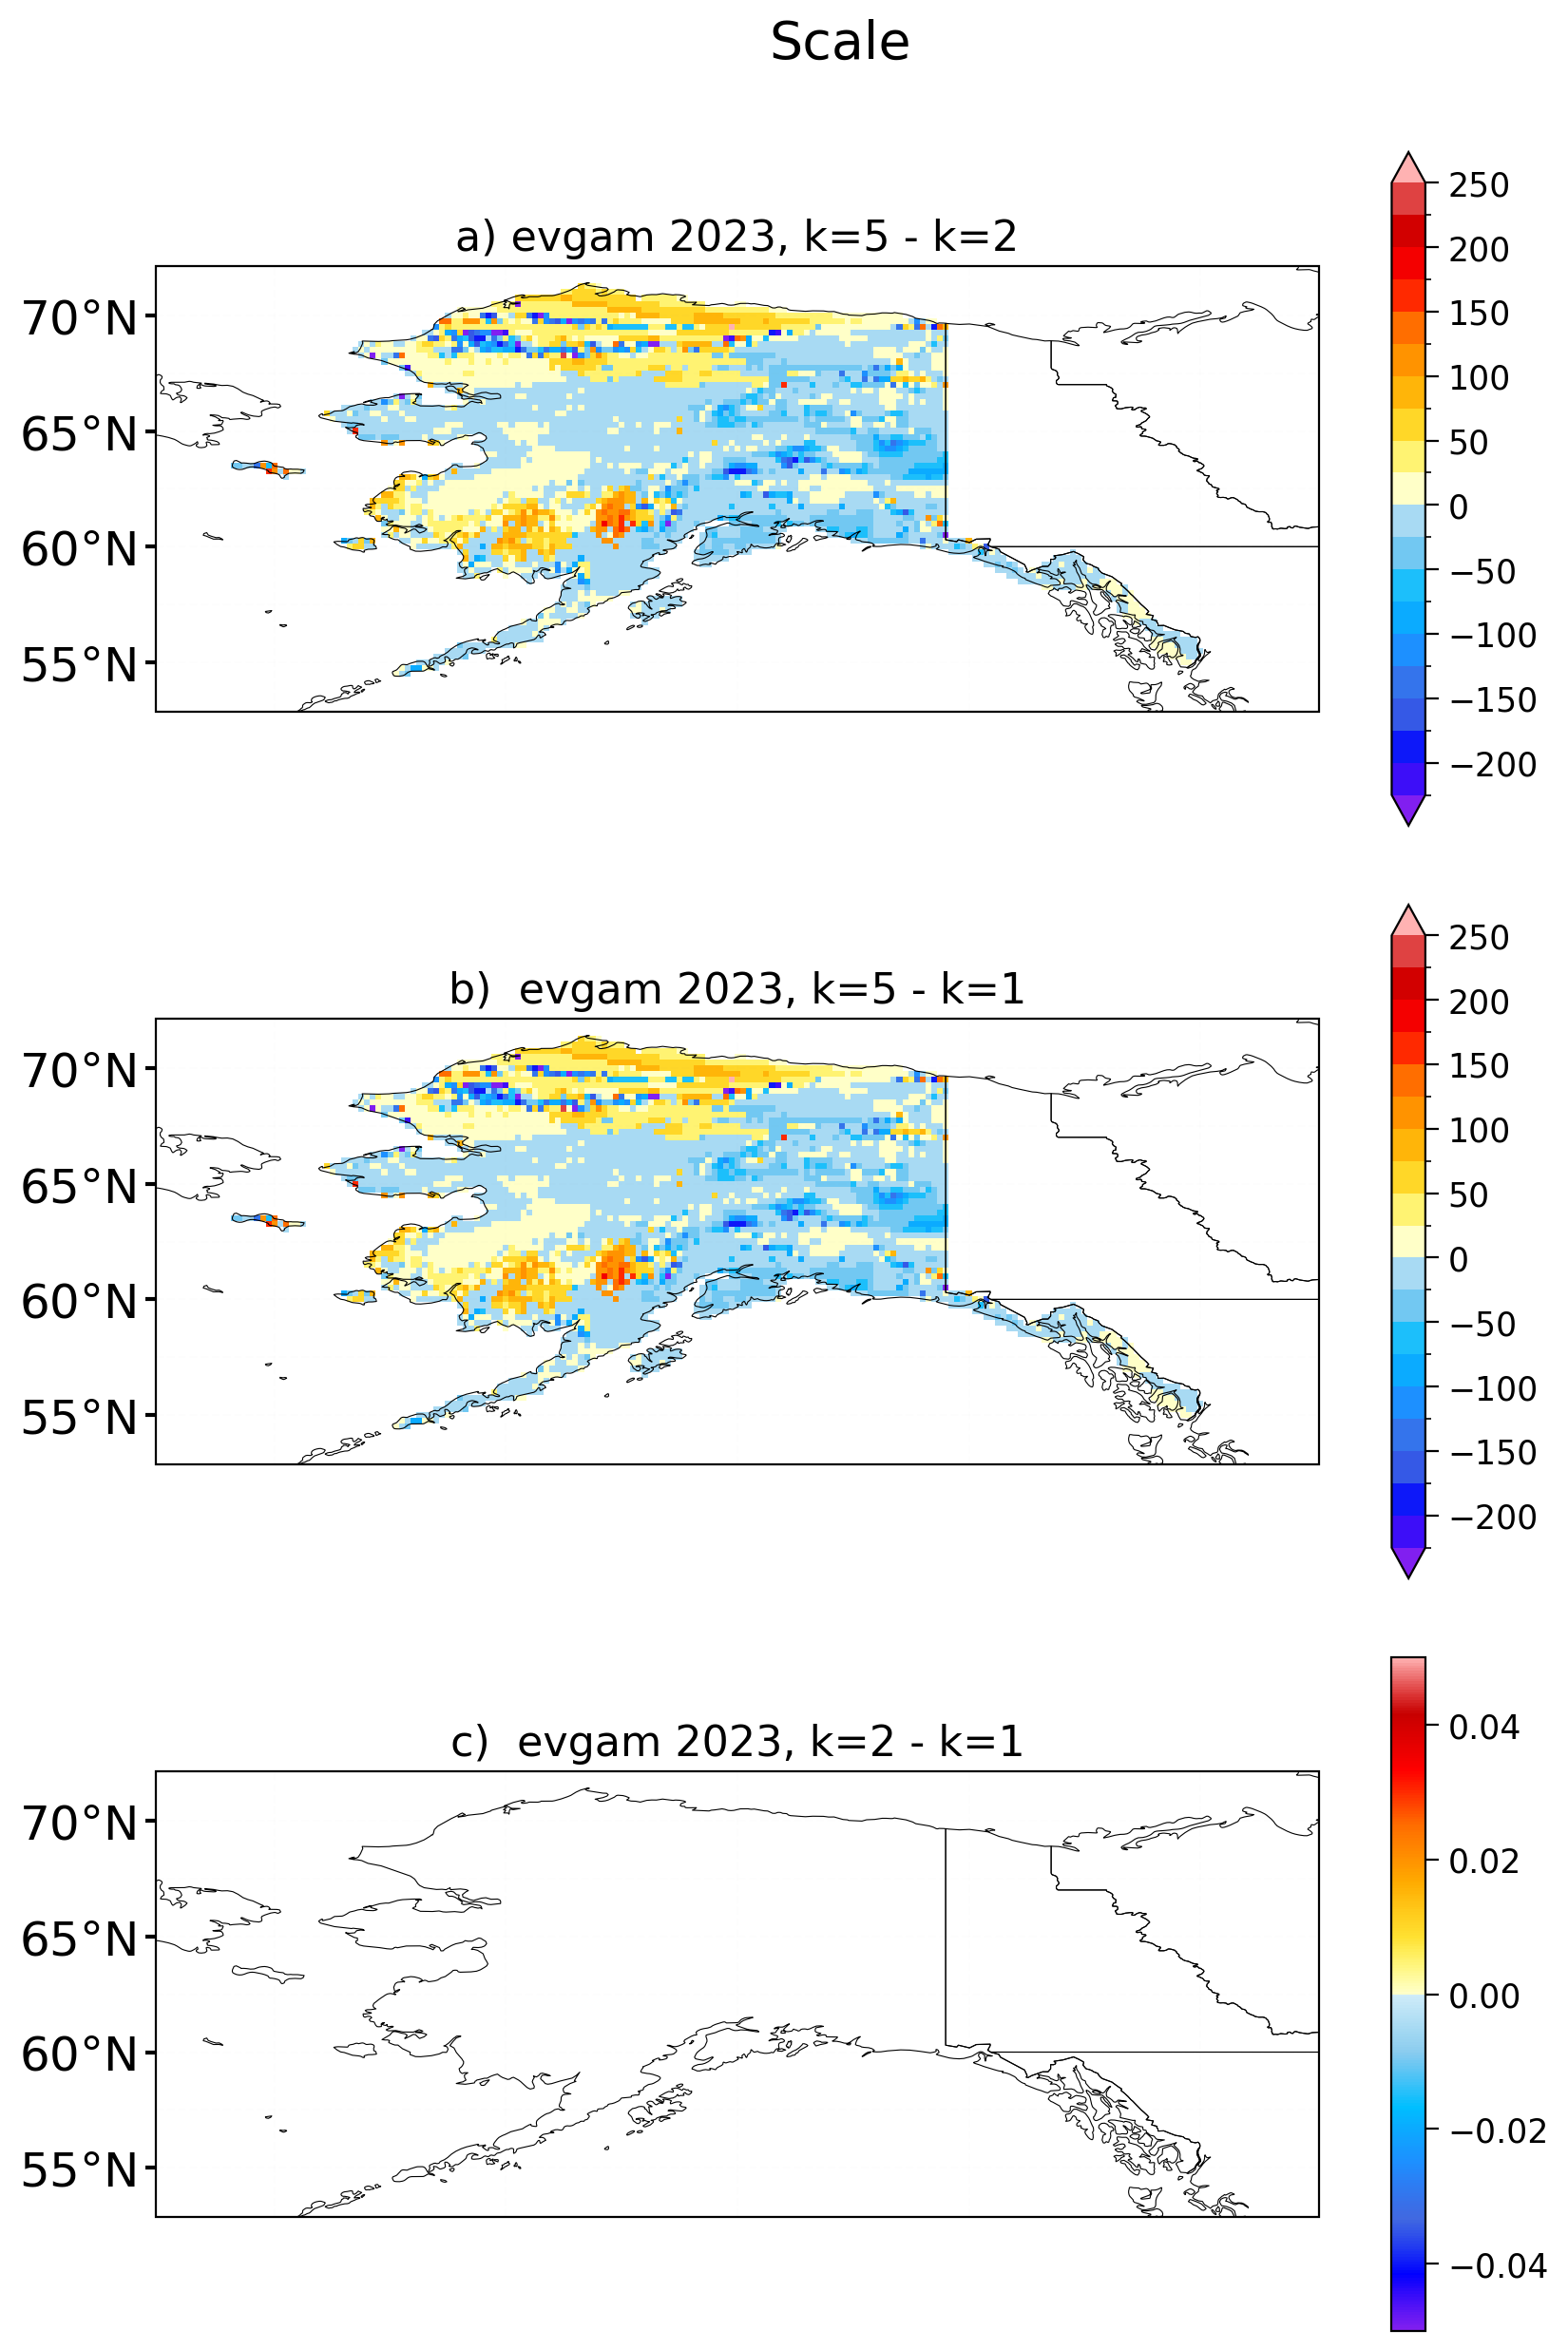

In [55]:
fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  Scale
#
clevs = np.arange(-225,275,25)
data=Rscale5.sel(time=yeare) - Rscale2.sel(time=yeare)
data=data.where(data!=0.)
data.plot(ax=ax[0],cmap=cmapBR_ng,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title(f'a) evgam {yeare}, k=5 - k=2',fontsize=16)

data=Rscale5.sel(time=yeare) - Rscale1.sel(time=yeare)
data=data.where(data!=0.)
data.plot(ax=ax[1],cmap=cmapBR_ng,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'b)  evgam {yeare}, k=5 - k=1',fontsize=16)

data=Rscale2.sel(time=yeare) - Rscale1.sel(time=yeare)
data=data.where(data!=0.)
data.plot(ax=ax[2],cmap=cmapBR_ng,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'c)  evgam {yeare}, k=2 - k=1',fontsize=16)
clevs = np.arange(0,500,25)

####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('Scale',fontsize=20)    
outfile=f'PLOTS/GEV_scale_{yeare}_NS{itest}.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

Map of difference of scale parameters from EVGAM with scale smoothing a) k=5 - k=2, b) k=5 -k=1 , and c) k=2 - k=1. Masked when there is no difference. 

# Plot Shape

<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/1933263656.py:36: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/1933263656.py:39: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


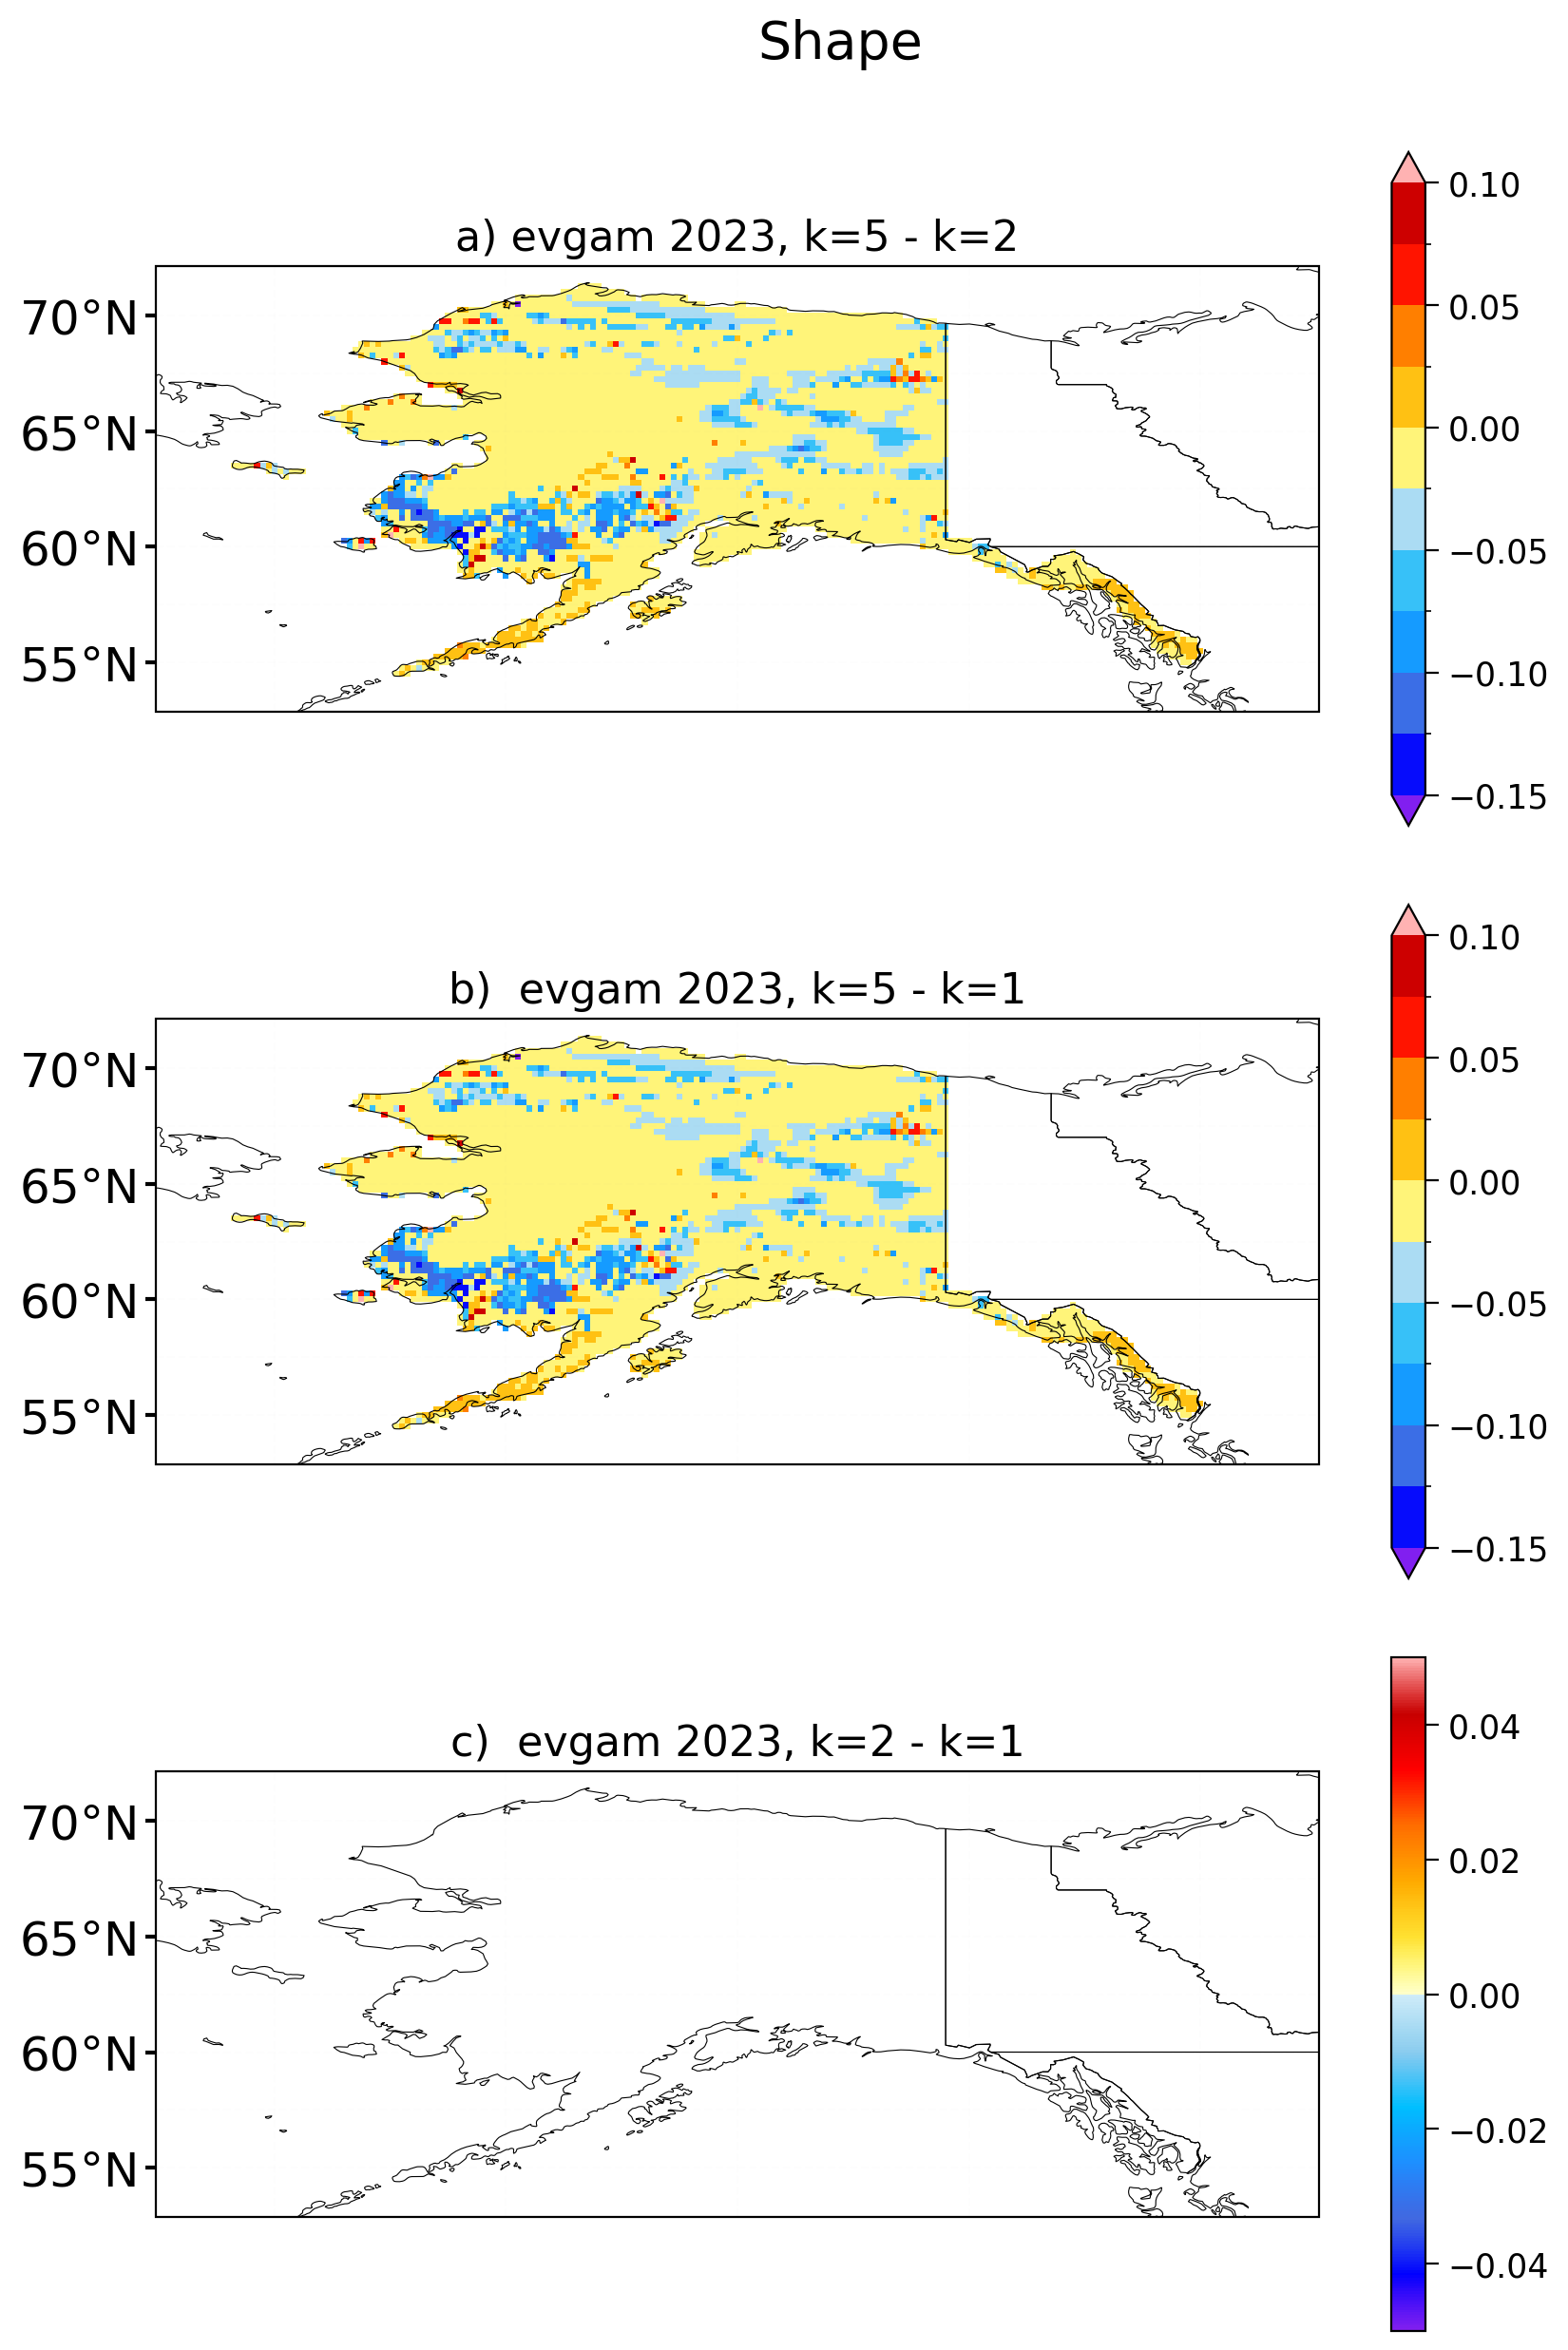

In [56]:
fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  Scale
#
clevs = np.arange(-.15,.125,0.025)

data=Rshape5.sel(time=yeare) - Rshape2.sel(time=yeare)
data=data.where(data!=0.)
data.plot(ax=ax[0],cmap=cmapBR_ng,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title(f'a) evgam {yeare}, k=5 - k=2',fontsize=16)

data=Rshape5.sel(time=yeare) - Rshape1.sel(time=yeare)
data=data.where(data!=0.)
data.plot(ax=ax[1],cmap=cmapBR_ng,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'b)  evgam {yeare}, k=5 - k=1',fontsize=16)

data=Rshape2.sel(time=yeare) - Rshape1.sel(time=yeare)
data=data.where(data!=0.)
data.plot(ax=ax[2],cmap=cmapBR_ng,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'c)  evgam {yeare}, k=2 - k=1',fontsize=16)

####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('Shape',fontsize=20)    
outfile=f'PLOTS/GEV_shape_NS{itest}.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

Map of difference of shape parameters from EVGAM with scale smoothing a) k=5 - k=2, b) k=5 -k=1 , and c) k=2 - k=1. Masked when there is no difference. 

# Plot 100y Return Level 

<>:35: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:35: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/814891314.py:35: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/814891314.py:38: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


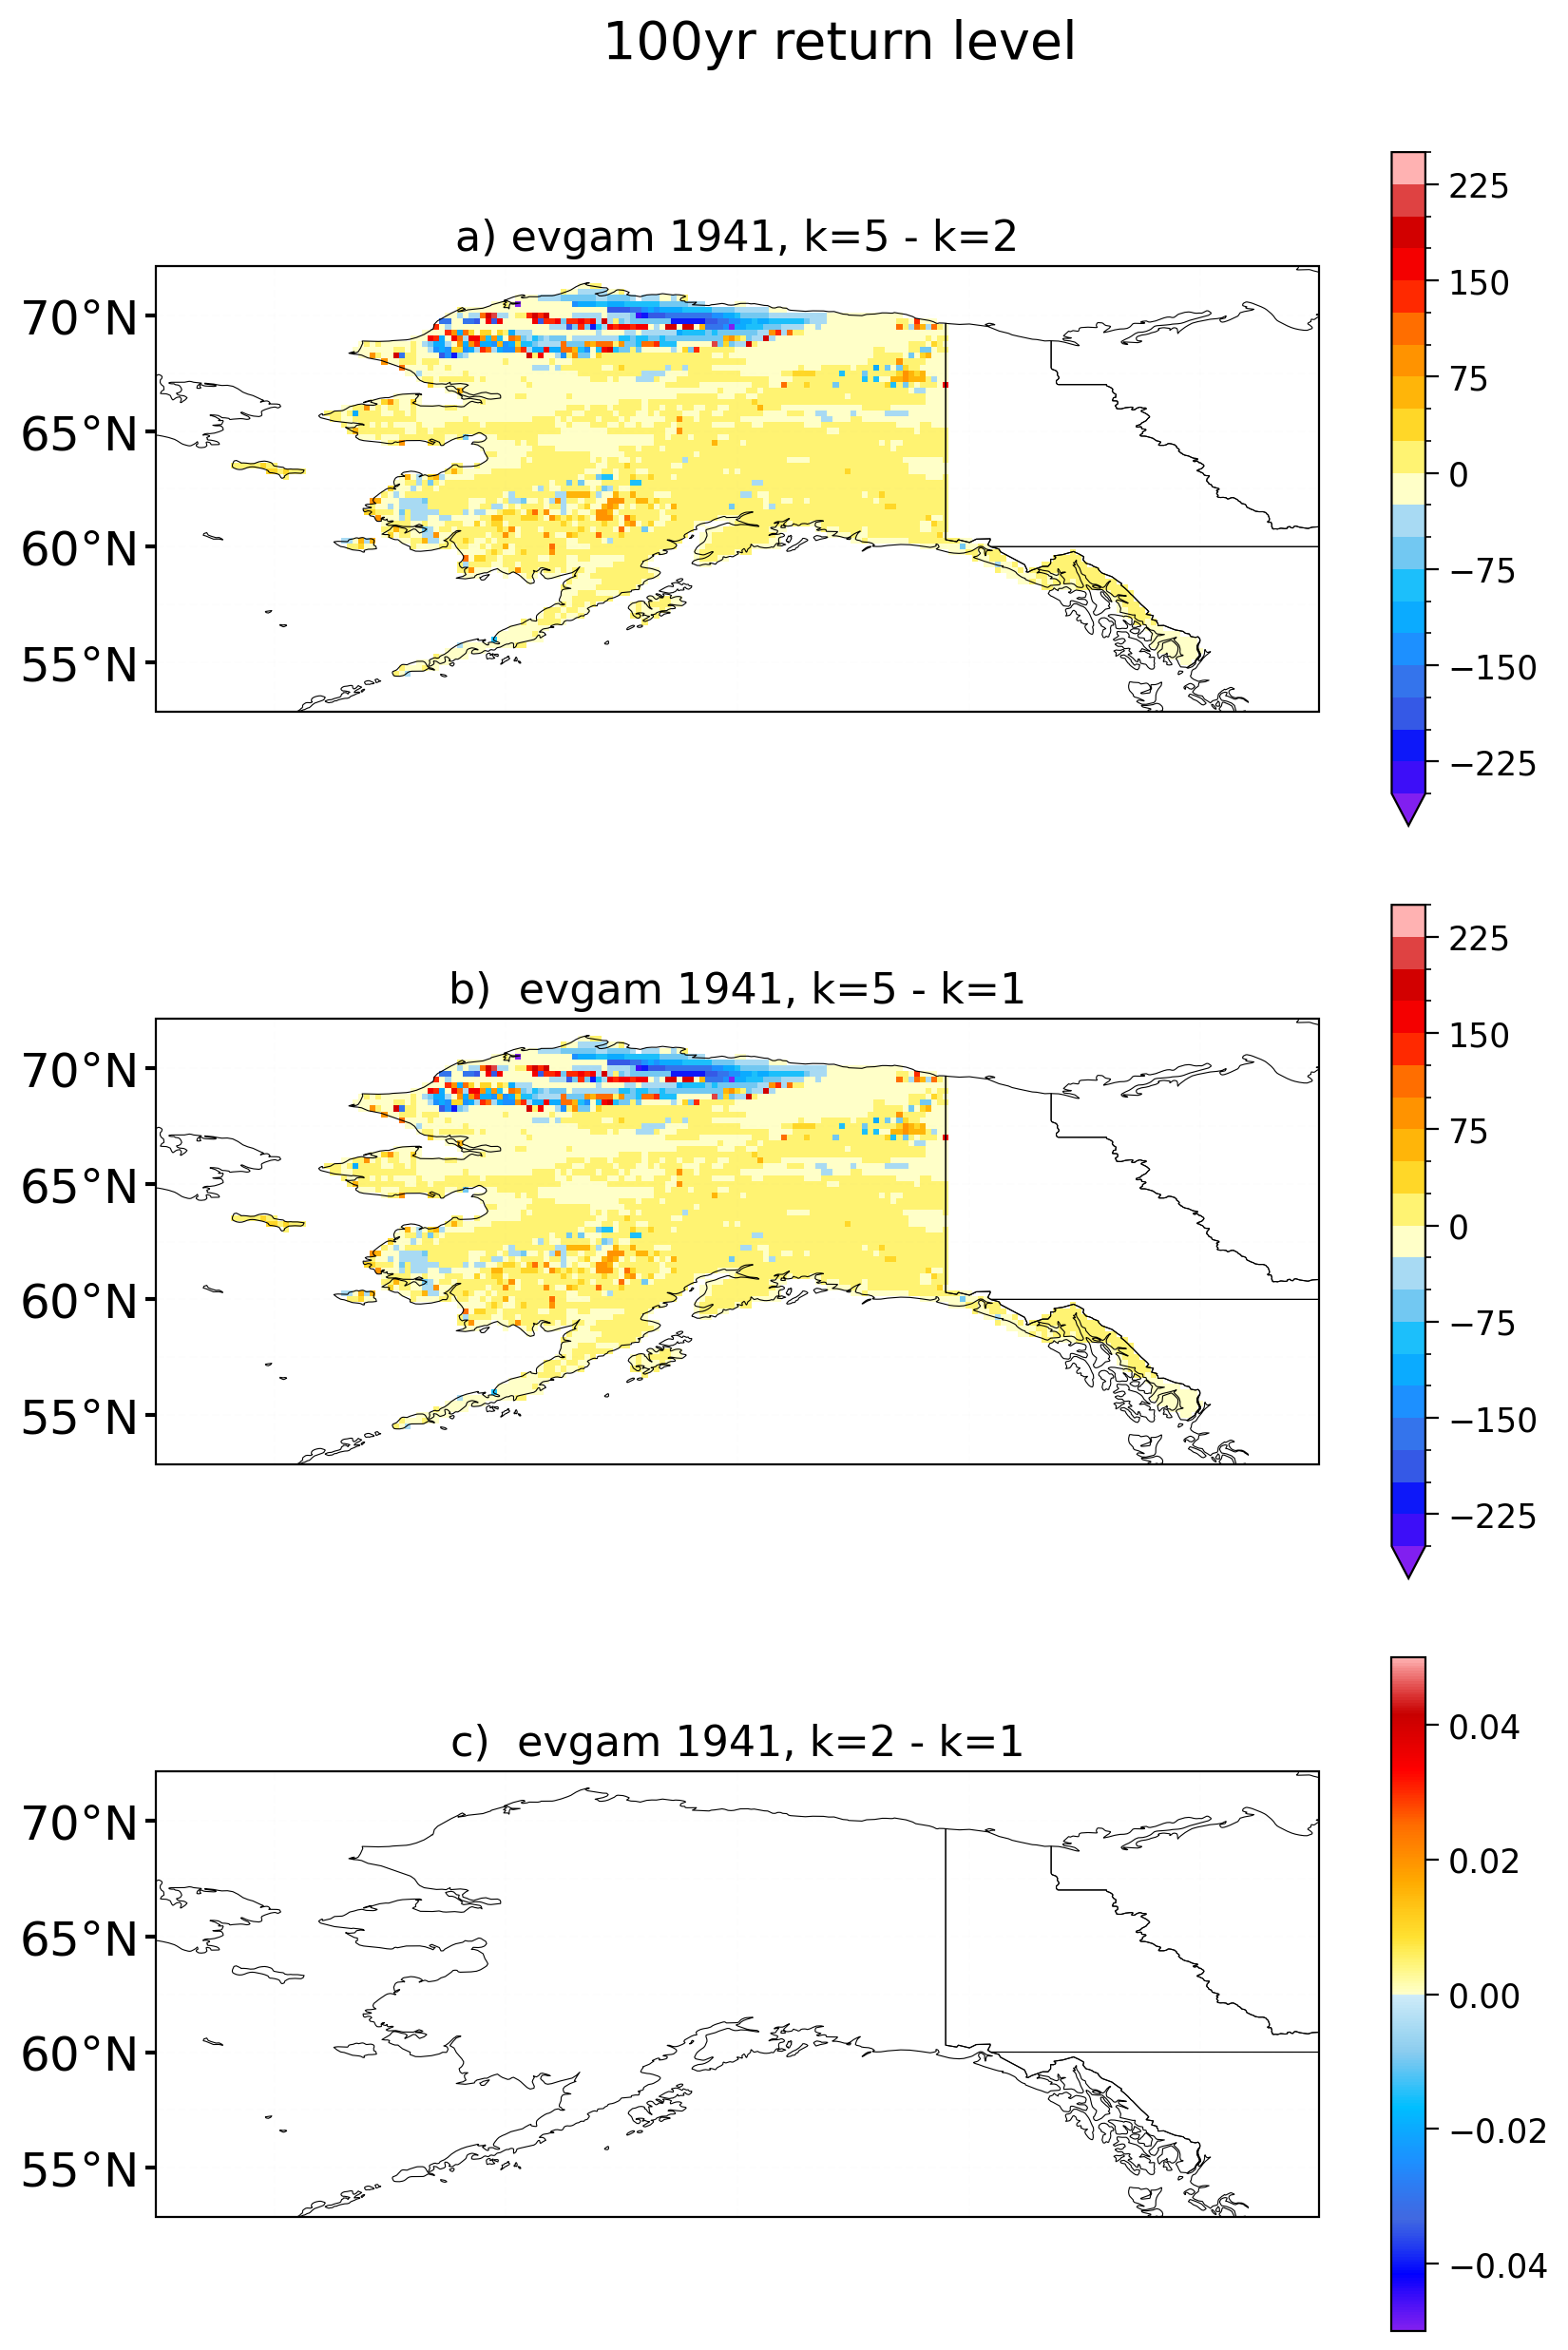

In [57]:
fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  RL100
#
clevs = np.arange(-250,275,25)
data=Rrl1005.sel(time=yearb) - Rrl1002.sel(time=yearb)
data=data.where(data!=0.)
data.plot(ax=ax[0],cmap=cmapBR_ng,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title(f'a) evgam {yearb}, k=5 - k=2',fontsize=16)

data=Rrl1005.sel(time=yearb) - Rrl1001.sel(time=yearb)
data=data.where(data!=0.)
data.plot(ax=ax[1],cmap=cmapBR_ng,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'b)  evgam {yearb}, k=5 - k=1',fontsize=16)

data=Rrl1002.sel(time=yearb) - Rrl1001.sel(time=yearb)
data=data.where(data!=0.)
data.plot(ax=ax[2],cmap=cmapBR_ng,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'c)  evgam {yearb}, k=2 - k=1',fontsize=16)

####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('100yr return level',fontsize=20)    
outfile=f'PLOTS/GEV_rl100_{yearb}_NS{itest}.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

Map of difference of 100yr return level from EVGAM with scale smoothing a) k=5 - k=2, b) k=5 -k=1 , and c) k=2 - k=1. Masked when there is no difference. 

<>:35: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:35: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/2485647851.py:35: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/2485647851.py:38: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


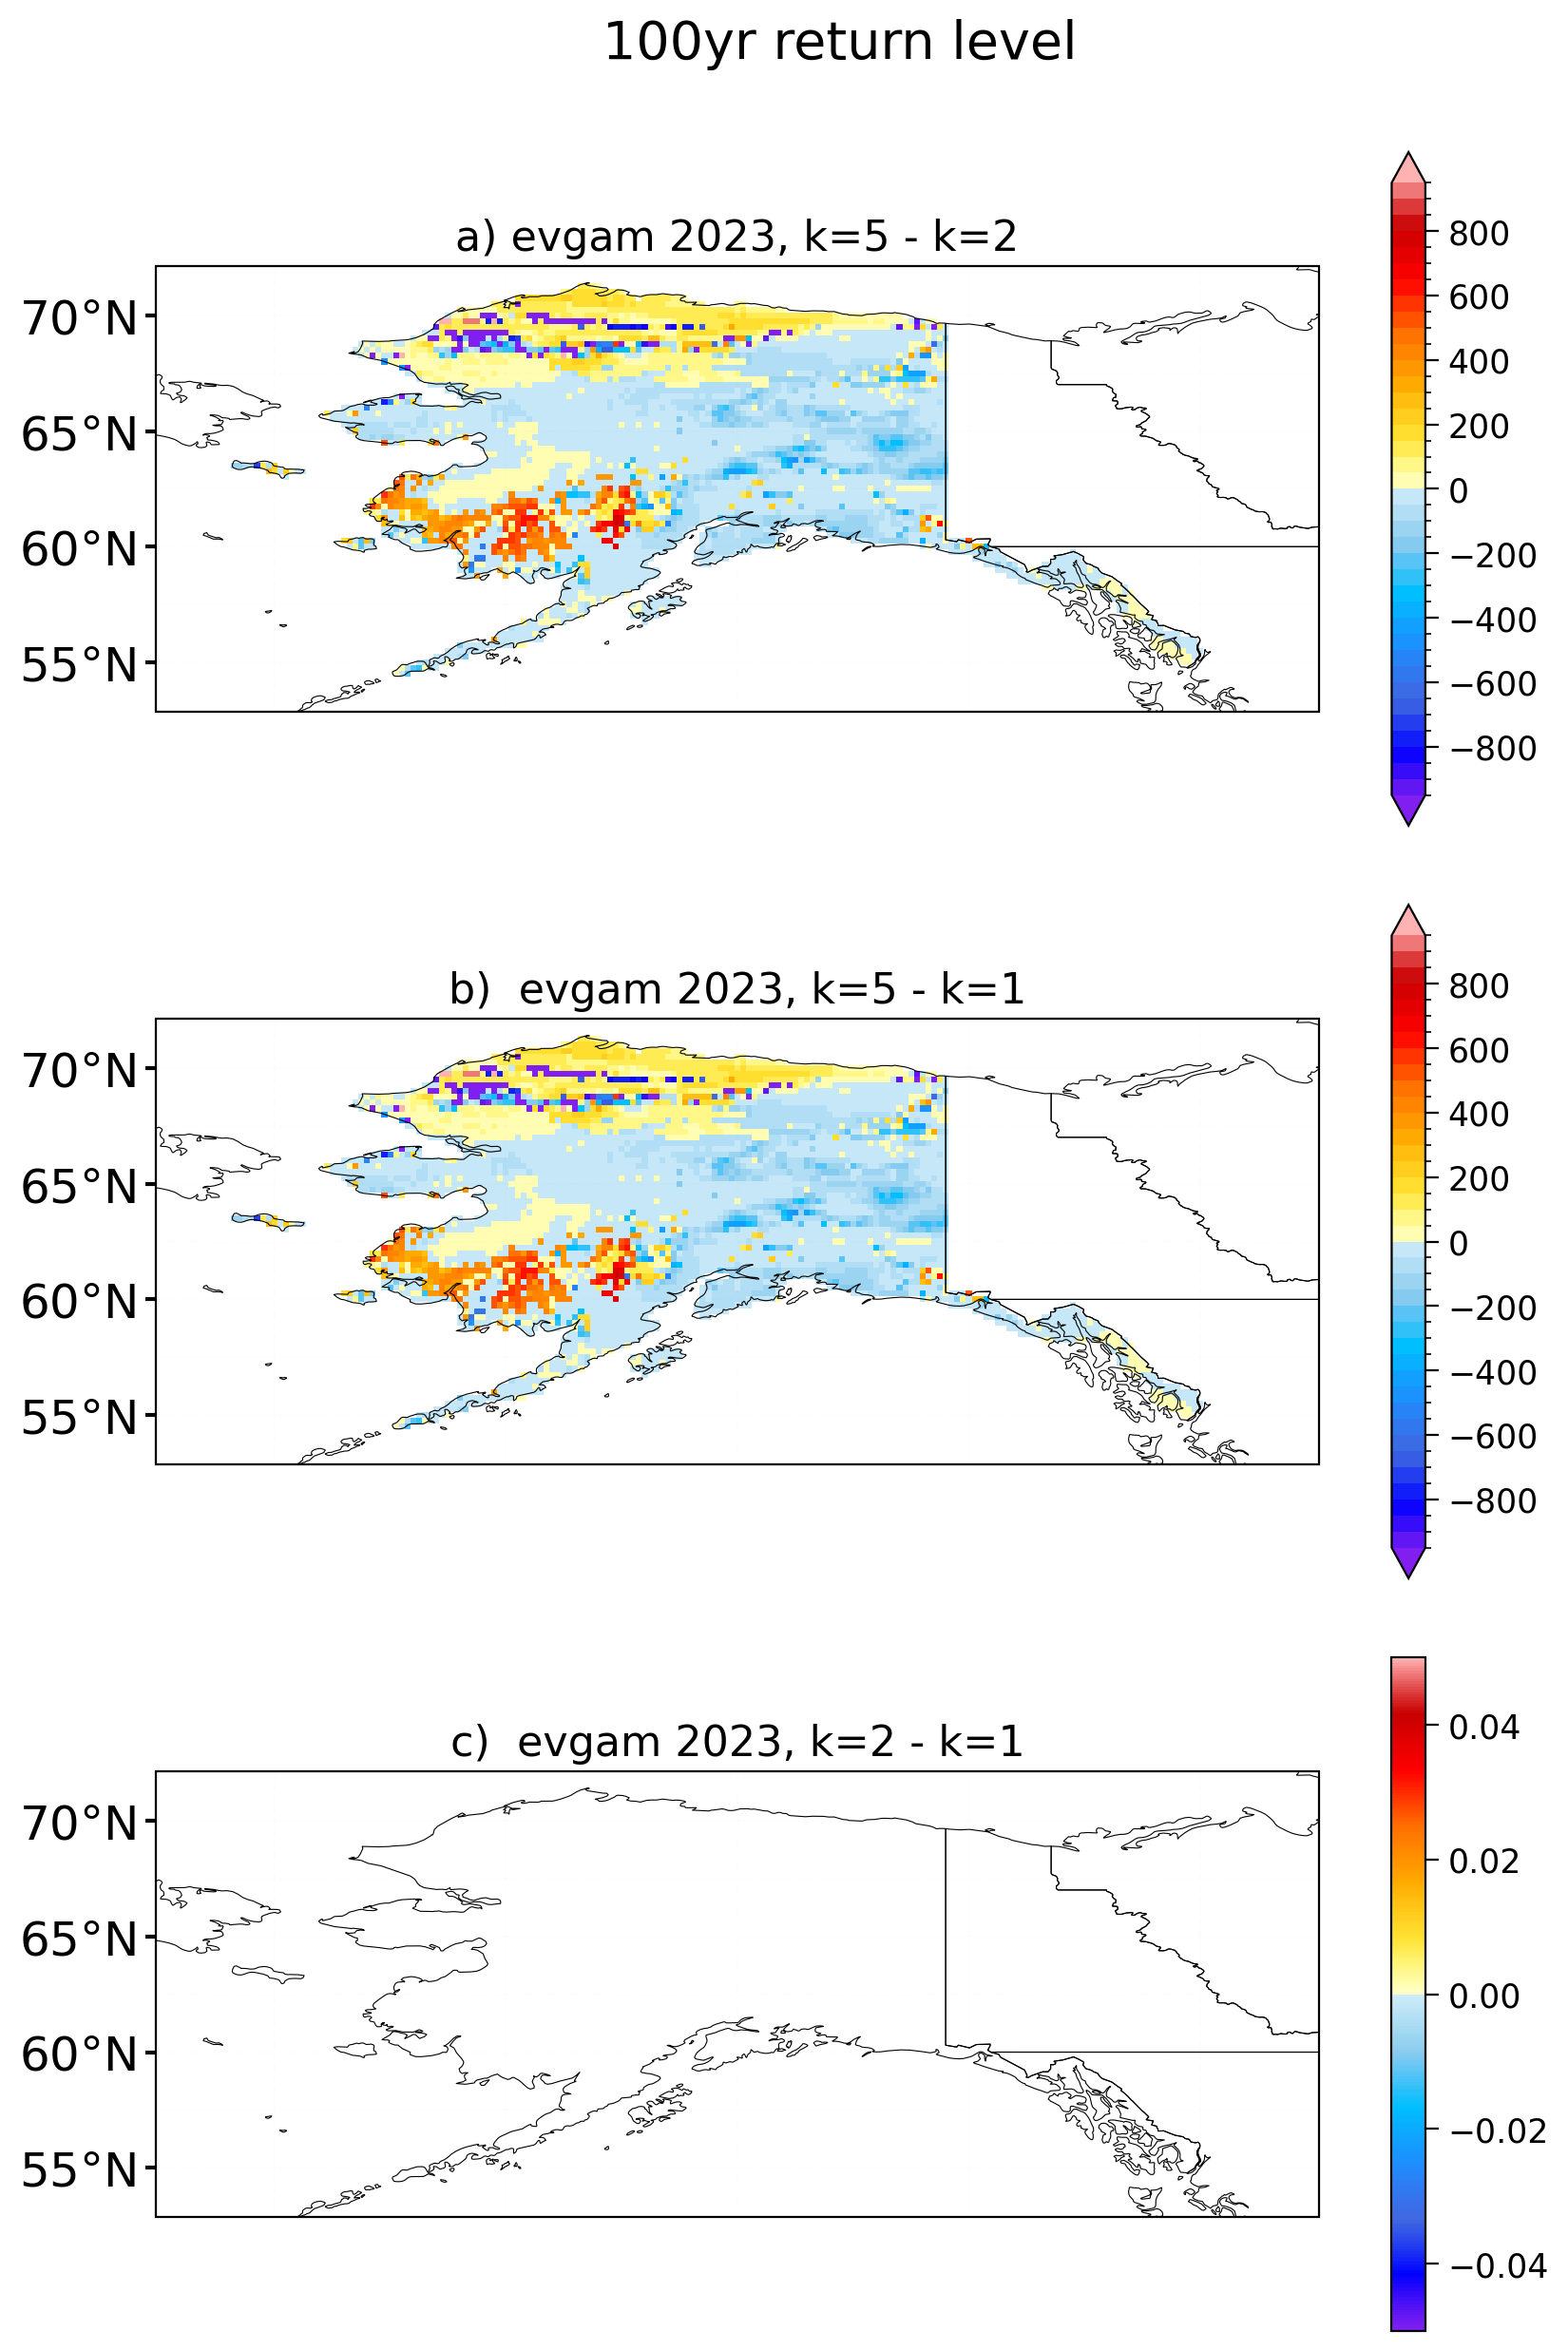

In [58]:
fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  RL100
#
clevs = np.arange(-950,1000,50)
data=Rrl1005.sel(time=yeare) - Rrl1002.sel(time=yeare)
data=data.where(data!=0.)
data.plot(ax=ax[0],cmap=cmapBR_ng,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title(f'a) evgam {yeare}, k=5 - k=2',fontsize=16)

data=Rrl1005.sel(time=yeare) - Rrl1001.sel(time=yeare)
data=data.where(data!=0.)
data.plot(ax=ax[1],cmap=cmapBR_ng,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'b)  evgam {yeare}, k=5 - k=1',fontsize=16)

data=Rrl1002.sel(time=yeare) - Rrl1001.sel(time=yeare)
data=data.where(data!=0.)
data.plot(ax=ax[2],cmap=cmapBR_ng,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'c)  evgam {yeare}, k=2 - k=1',fontsize=16)

####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('100yr return level',fontsize=20)    
outfile=f'PLOTS/GEV_rl100_{yeare}_NS{itest}.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

Map of difference of 100yr return level from EVGAM with scale smoothing a) k=5 - k=2, b) k=5 -k=1 , and c) k=2 - k=1. Masked when there is no difference. 

# GRID POINTS ANALYSIS

In [59]:
ptlon=[210,211.]
ptlat=[ 60.25, 64.75  ]

<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/2737078108.py:19: SyntaxWarning: invalid escape sequence '\d'
  ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_35528/2737078108.py:22: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)


Text(0.5, 1.0, '100yr return level,2023-1941')

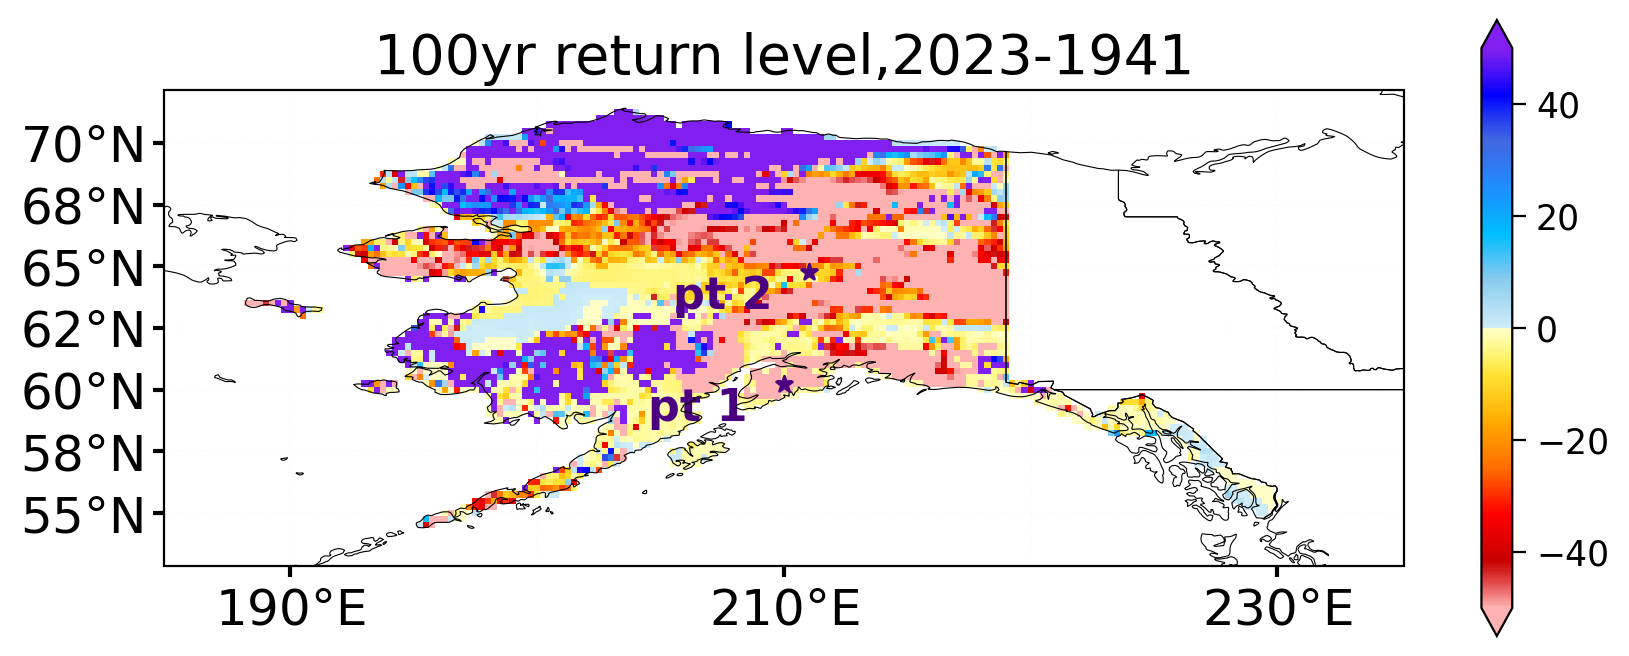

In [60]:
cmap=cmaps.BlGrYeOrReVi200

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,8),subplot_kw={'projection':proj})
data=Rrl1005.sel(time=yeare) - Rrl1002.sel(time=yeare)
data=data.where(data!=0.)
data.plot(cmap=cmapBR_rng,vmin=-50,vmax=50,cbar_kwargs={'label':'','shrink':0.5})
for ip in range(0,len(ptlon)):
  ax.scatter(ptlon[ip],ptlat[ip],marker='*',color='indigo')
  ax.text(ptlon[ip]-360-5.5,ptlat[ip]-1.5,f'pt {ip+1}',color='indigo',size=16,weight='bold')

grd = ax.gridlines(
  draw_labels=False, 
  color='gray', alpha=0.01, linestyle='--')
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both',direction='out',width=1.5,length=4)
ax.set_yticks(ax.get_yticks()[1:-1],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)

ax.set_xticks(ax.get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)
ax.set_title(f'100yr return level,{yeare}-{yearb}',fontsize=20)

Map of difference of 100yr return level from EVGAM with scale smoothing k=5 - k=2.


<>:82: SyntaxWarning: invalid escape sequence '\d'
<>:84: SyntaxWarning: invalid escape sequence '\d'
<>:84: SyntaxWarning: invalid escape sequence '\d'
<>:99: SyntaxWarning: invalid escape sequence '\d'
<>:99: SyntaxWarning: invalid escape sequence '\d'
<>:112: SyntaxWarning: invalid escape sequence '\d'
<>:116: SyntaxWarning: invalid escape sequence '\d'
<>:116: SyntaxWarning: invalid escape sequence '\d'
<>:125: SyntaxWarning: invalid escape sequence '\d'
<>:134: SyntaxWarning: invalid escape sequence '\d'
<>:134: SyntaxWarning: invalid escape sequence '\d'
<>:143: SyntaxWarning: invalid escape sequence '\d'
<>:152: SyntaxWarning: invalid escape sequence '\d'
<>:152: SyntaxWarning: invalid escape sequence '\d'
<>:82: SyntaxWarning: invalid escape sequence '\d'
<>:84: SyntaxWarning: invalid escape sequence '\d'
<>:84: SyntaxWarning: invalid escape sequence '\d'
<>:99: SyntaxWarning: invalid escape sequence '\d'
<>:99: SyntaxWarning: invalid escape sequence '\d'
<>:112: SyntaxWarning:

In addition: Warning message:
In smooth.construct.tp.smooth.spec(object, dk$data, dk$knots) :
  basis dimension, k, increased to minimum possible



In addition: Warning message:
In smooth.construct.tp.smooth.spec(object, dk$data, dk$knots) :
  basis dimension, k, increased to minimum possible



#############
#############
Point 1
#############
#############
******
k=5
******


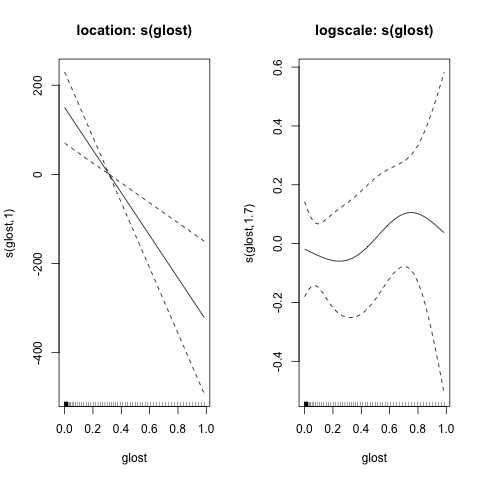


** Parametric terms **

location
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  1342.23      42.67   31.46   <2e-16

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     5.86       0.09   65.98   <2e-16

shape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)    -0.41       0.08   -5.29 6.17e-08

** Smooth terms **

location
         edf max.df Chi.sq Pr(>|t|)
s(glost)   1      4  14.08 0.000175

logscale
         edf max.df Chi.sq Pr(>|t|)
s(glost) 1.7      4   0.39    0.813
******
k=2
******


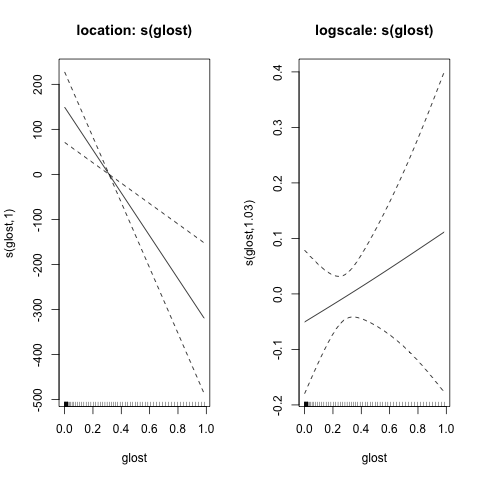


** Parametric terms **

location
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  1340.58      42.23   31.74   <2e-16

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     5.86       0.09   67.48   <2e-16

shape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)    -0.39       0.07   -5.57 1.25e-08

** Smooth terms **

location
         edf max.df Chi.sq Pr(>|t|)
s(glost)   1      4  14.56 0.000136

logscale
          edf max.df Chi.sq Pr(>|t|)
s(glost) 1.03      2   0.63    0.432
******
k=1
******


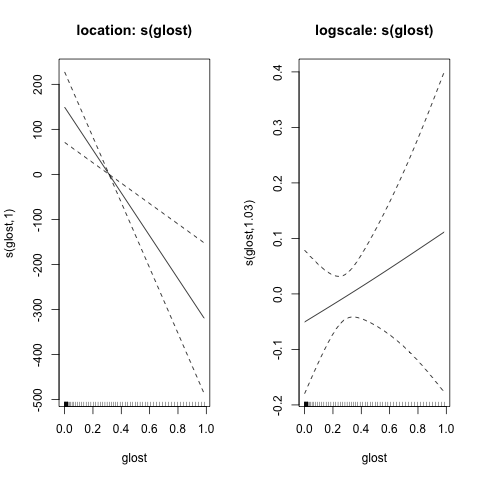


** Parametric terms **

location
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  1340.58      42.23   31.74   <2e-16

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     5.86       0.09   67.48   <2e-16

shape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)    -0.39       0.07   -5.57 1.25e-08

** Smooth terms **

location
         edf max.df Chi.sq Pr(>|t|)
s(glost)   1      4  14.56 0.000136

logscale
          edf max.df Chi.sq Pr(>|t|)
s(glost) 1.03      2   0.63    0.432


In addition: Warning message:
In smooth.construct.tp.smooth.spec(object, dk$data, dk$knots) :
  basis dimension, k, increased to minimum possible



In addition: Warning message:
In smooth.construct.tp.smooth.spec(object, dk$data, dk$knots) :
  basis dimension, k, increased to minimum possible



#############
#############
Point 2
#############
#############
******
k=5
******


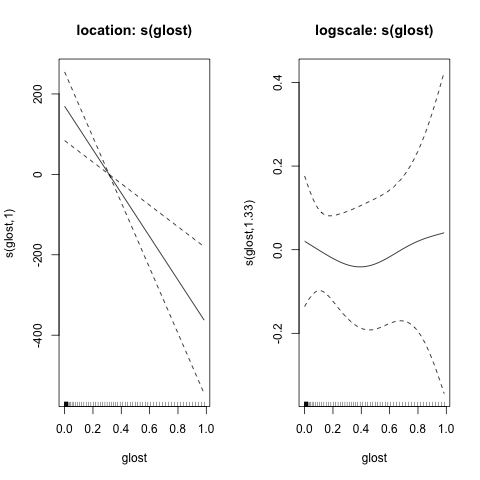


** Parametric terms **

location
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  2722.16      46.23   58.88   <2e-16

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     5.95       0.09   63.41   <2e-16

shape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)    -0.47       0.08   -5.64 8.52e-09

** Smooth terms **

location
         edf max.df Chi.sq Pr(>|t|)
s(glost)   1      4  15.74 7.27e-05

logscale
          edf max.df Chi.sq Pr(>|t|)
s(glost) 1.33      4   0.08    0.865
******
k=2
******


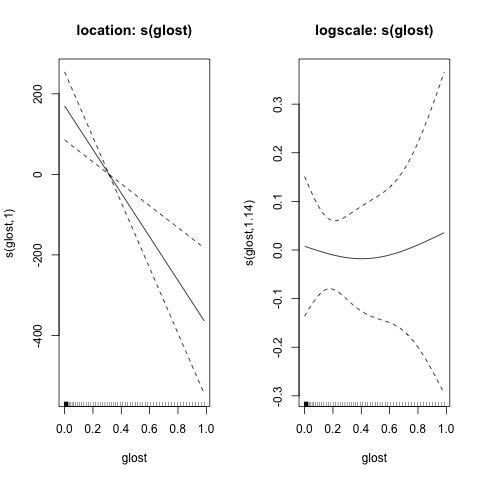


** Parametric terms **

location
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  2721.09      46.18   58.92   <2e-16

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     5.94       0.09   63.85   <2e-16

shape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)    -0.46       0.08   -5.67 7.03e-09

** Smooth terms **

location
         edf max.df Chi.sq Pr(>|t|)
s(glost)   1      4  16.16 5.82e-05

logscale
          edf max.df Chi.sq Pr(>|t|)
s(glost) 1.14      2   0.01     0.92
******
k=1
******


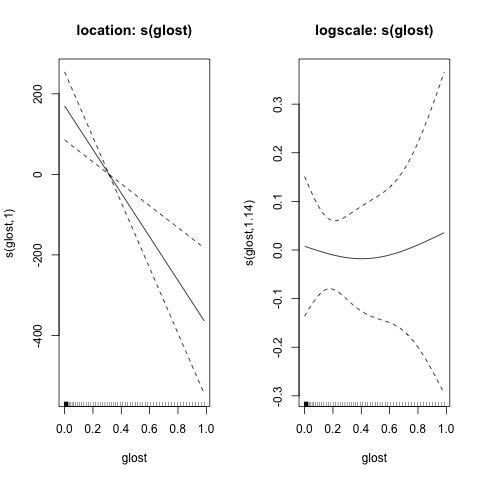


** Parametric terms **

location
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  2721.09      46.18   58.92   <2e-16

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     5.94       0.09   63.85   <2e-16

shape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)    -0.46       0.08   -5.67 7.03e-09

** Smooth terms **

location
         edf max.df Chi.sq Pr(>|t|)
s(glost)   1      4  16.16 5.82e-05

logscale
          edf max.df Chi.sq Pr(>|t|)
s(glost) 1.14      2   0.01     0.92


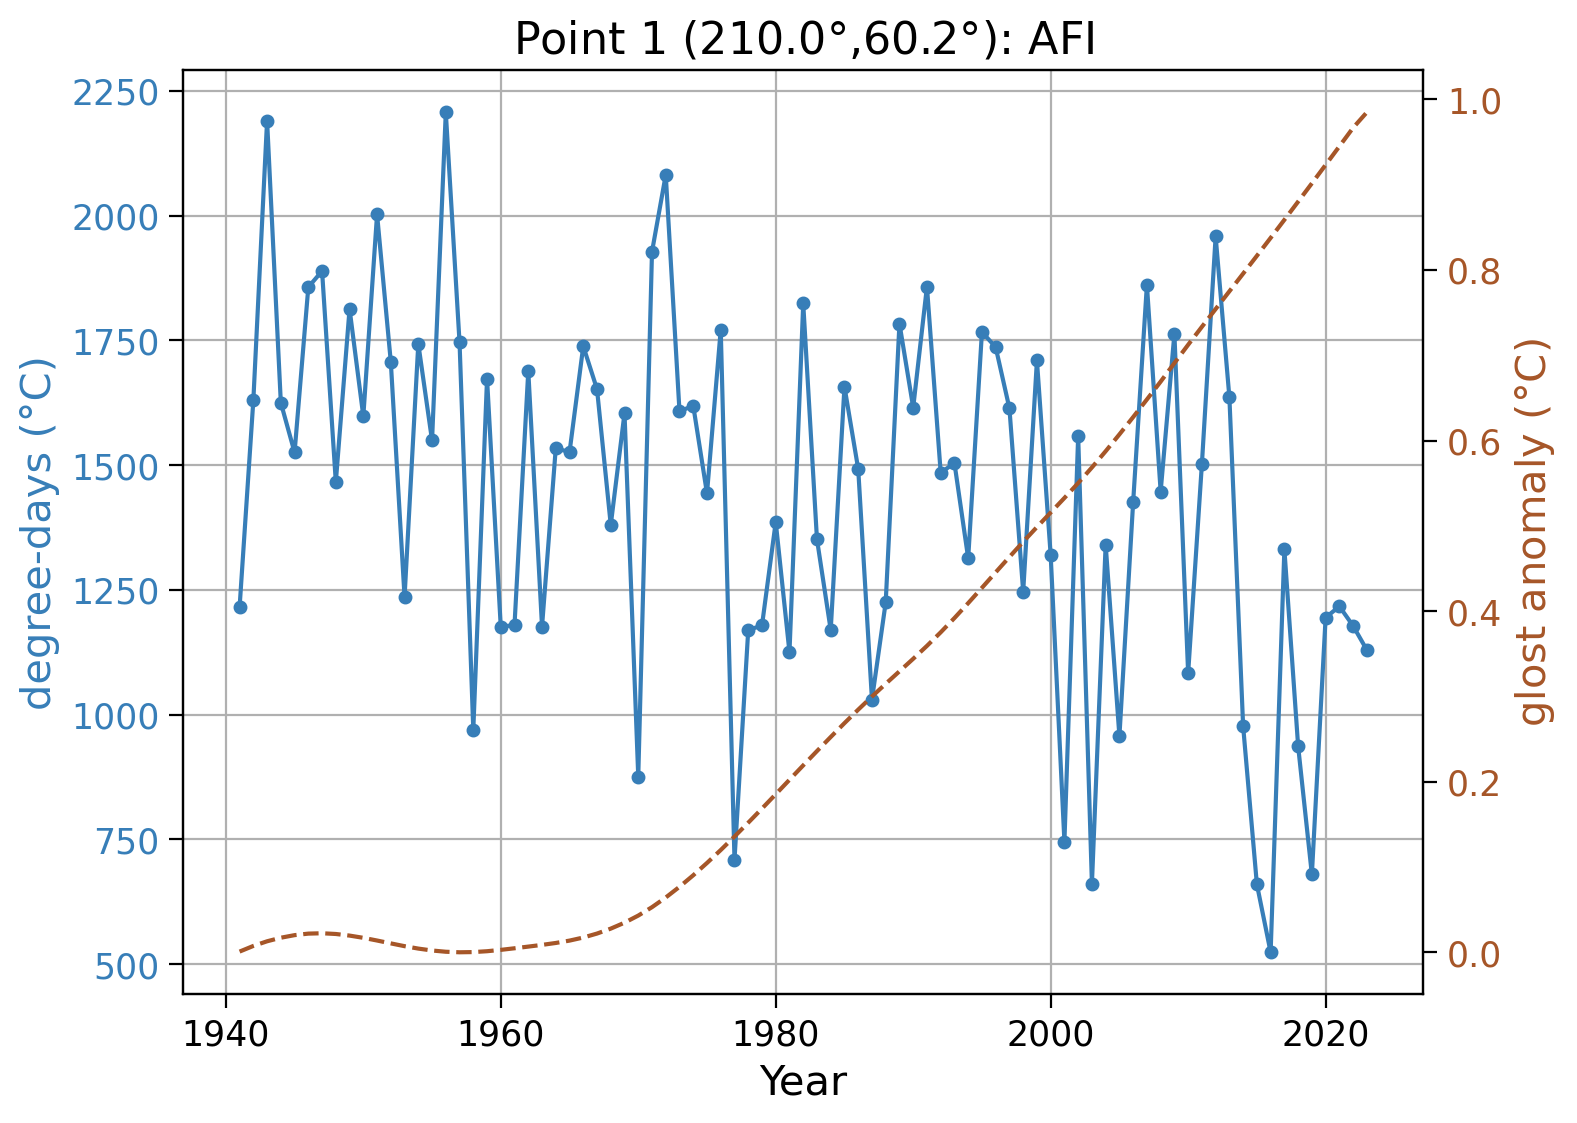

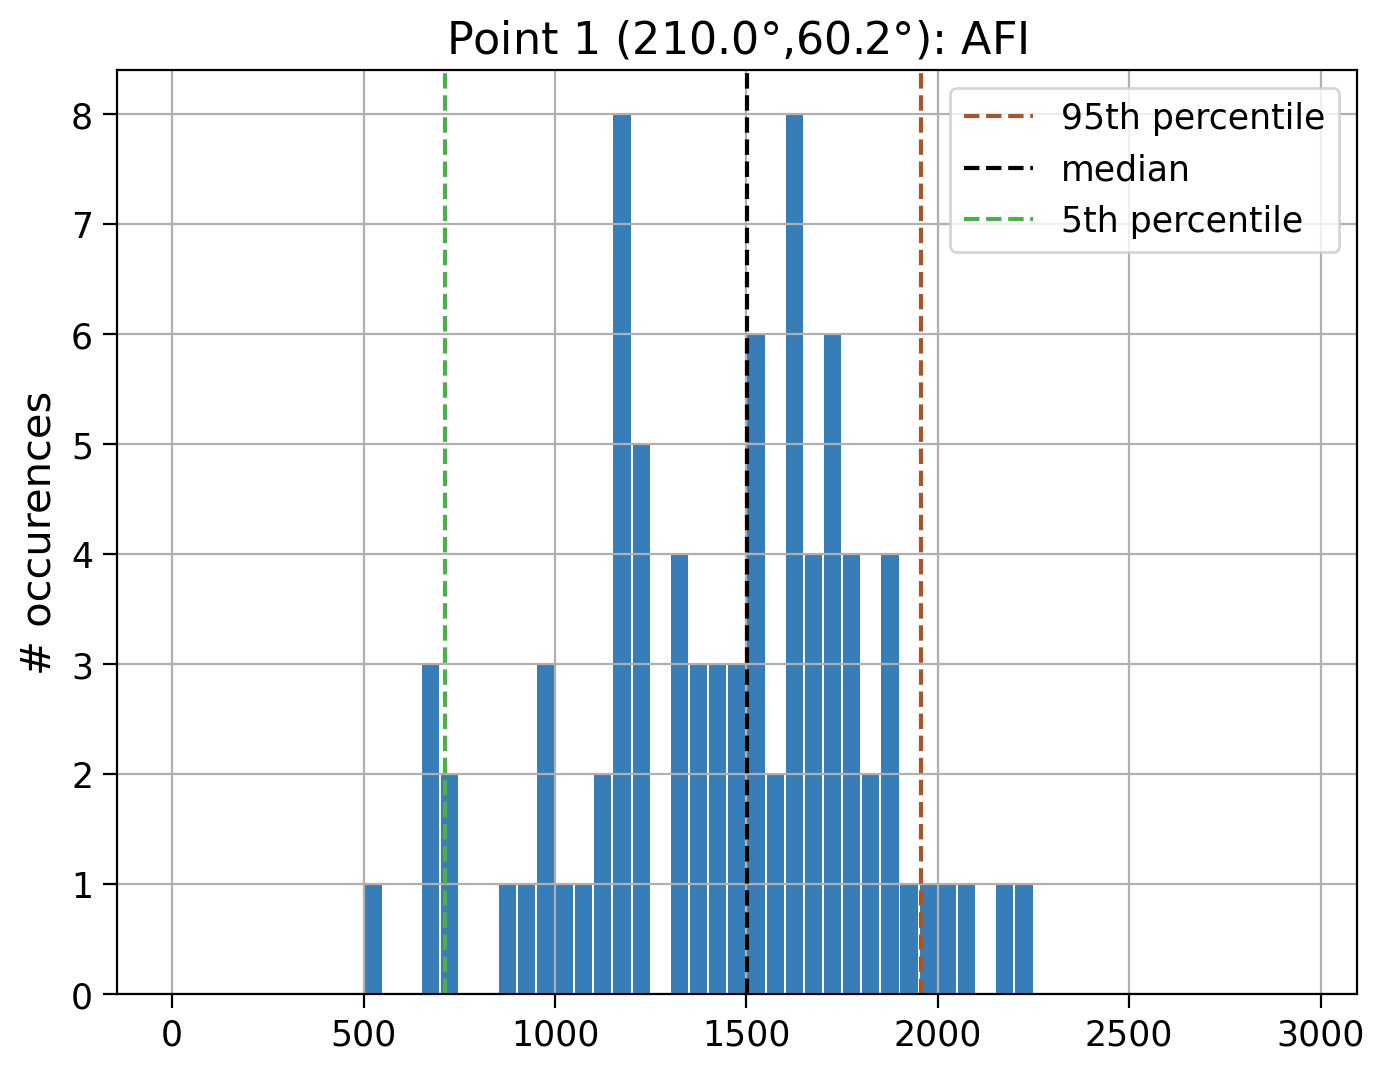

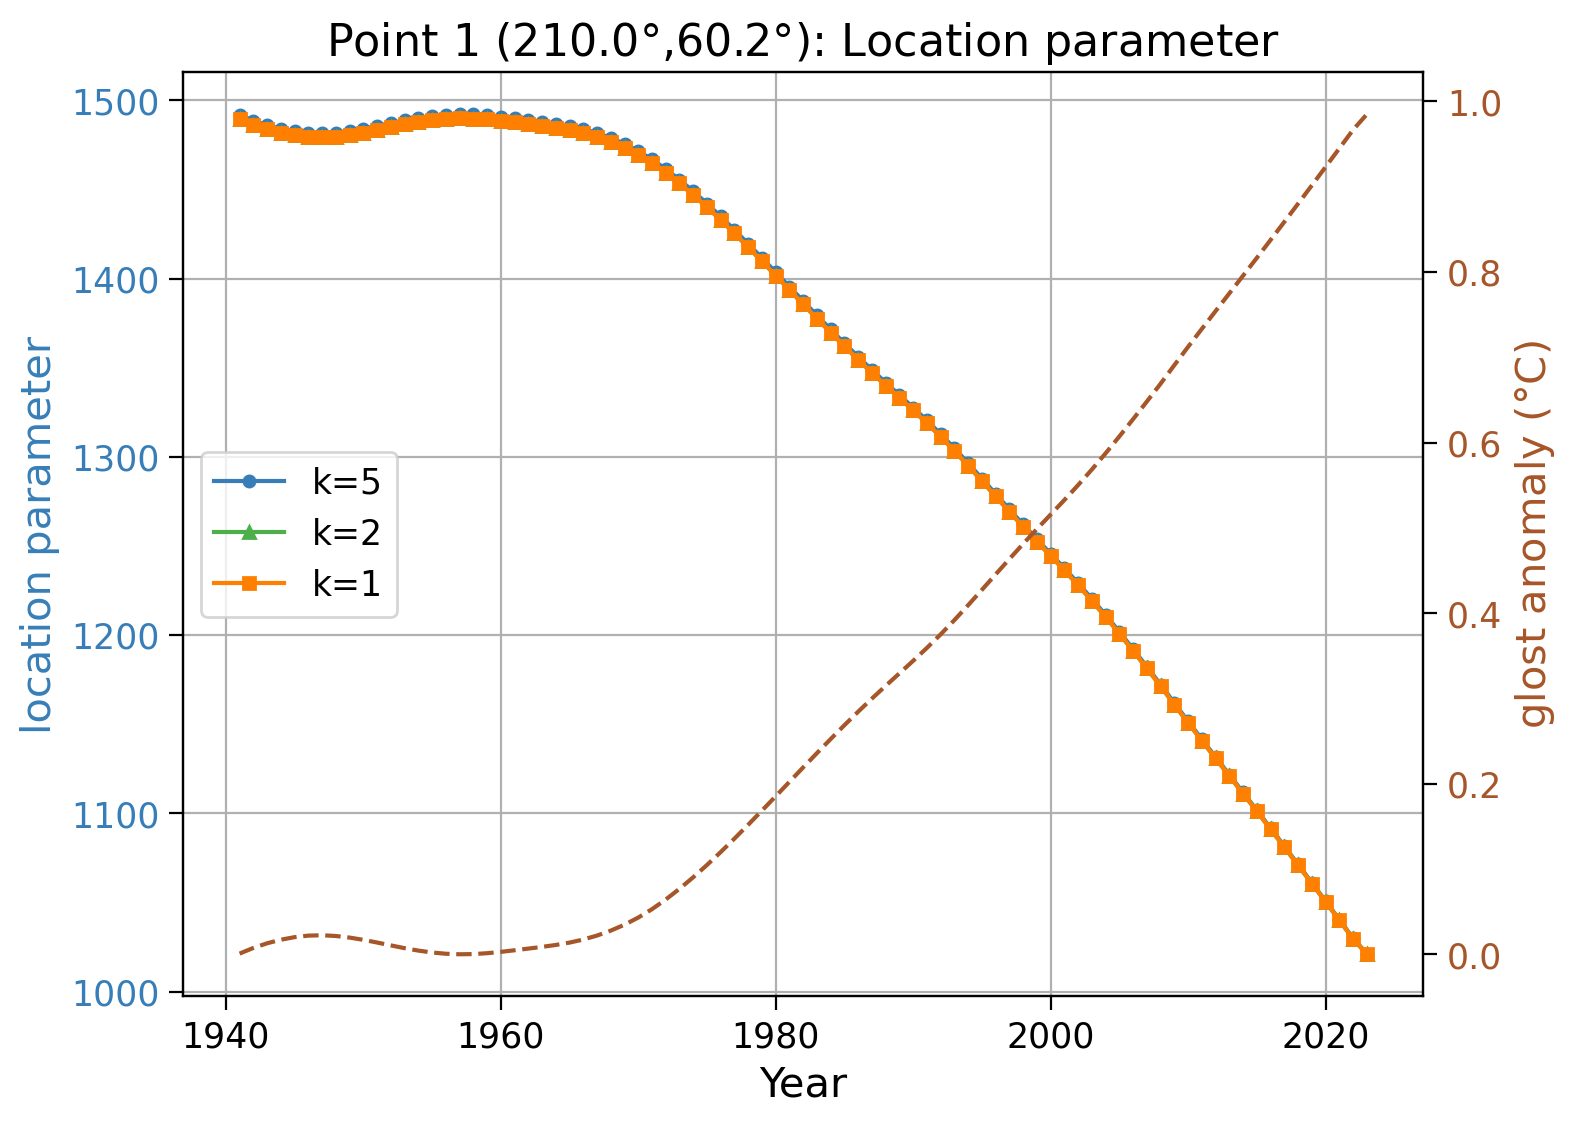

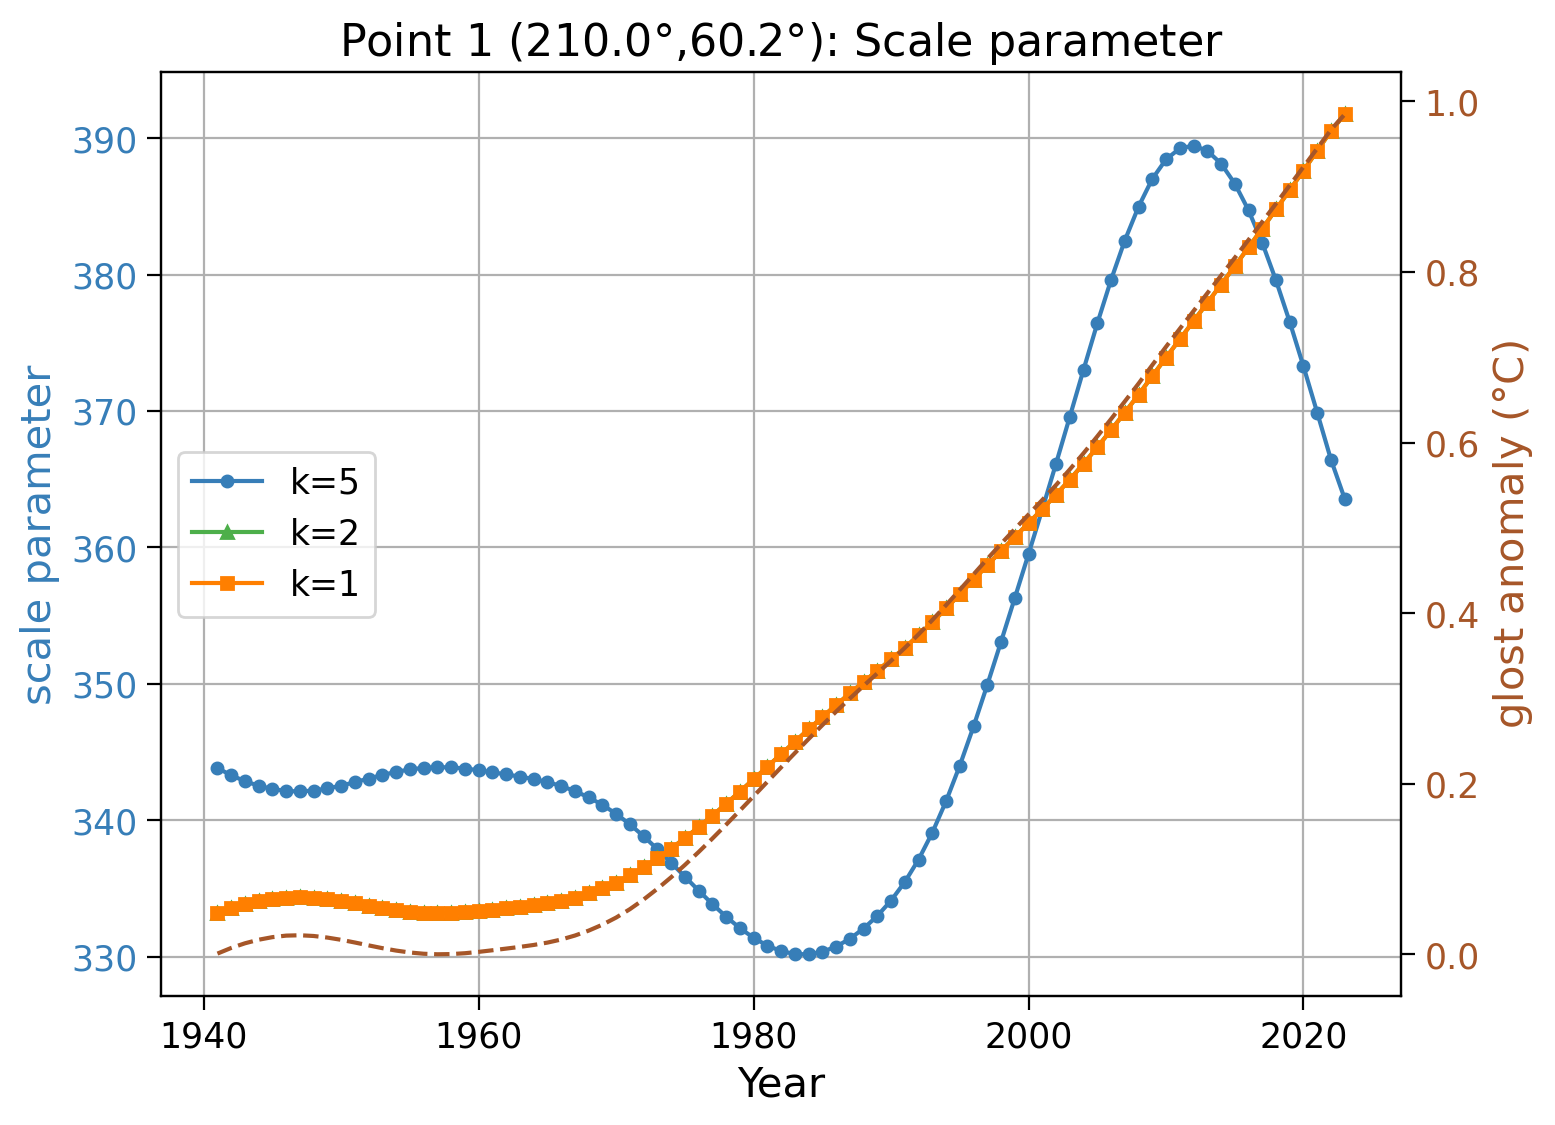

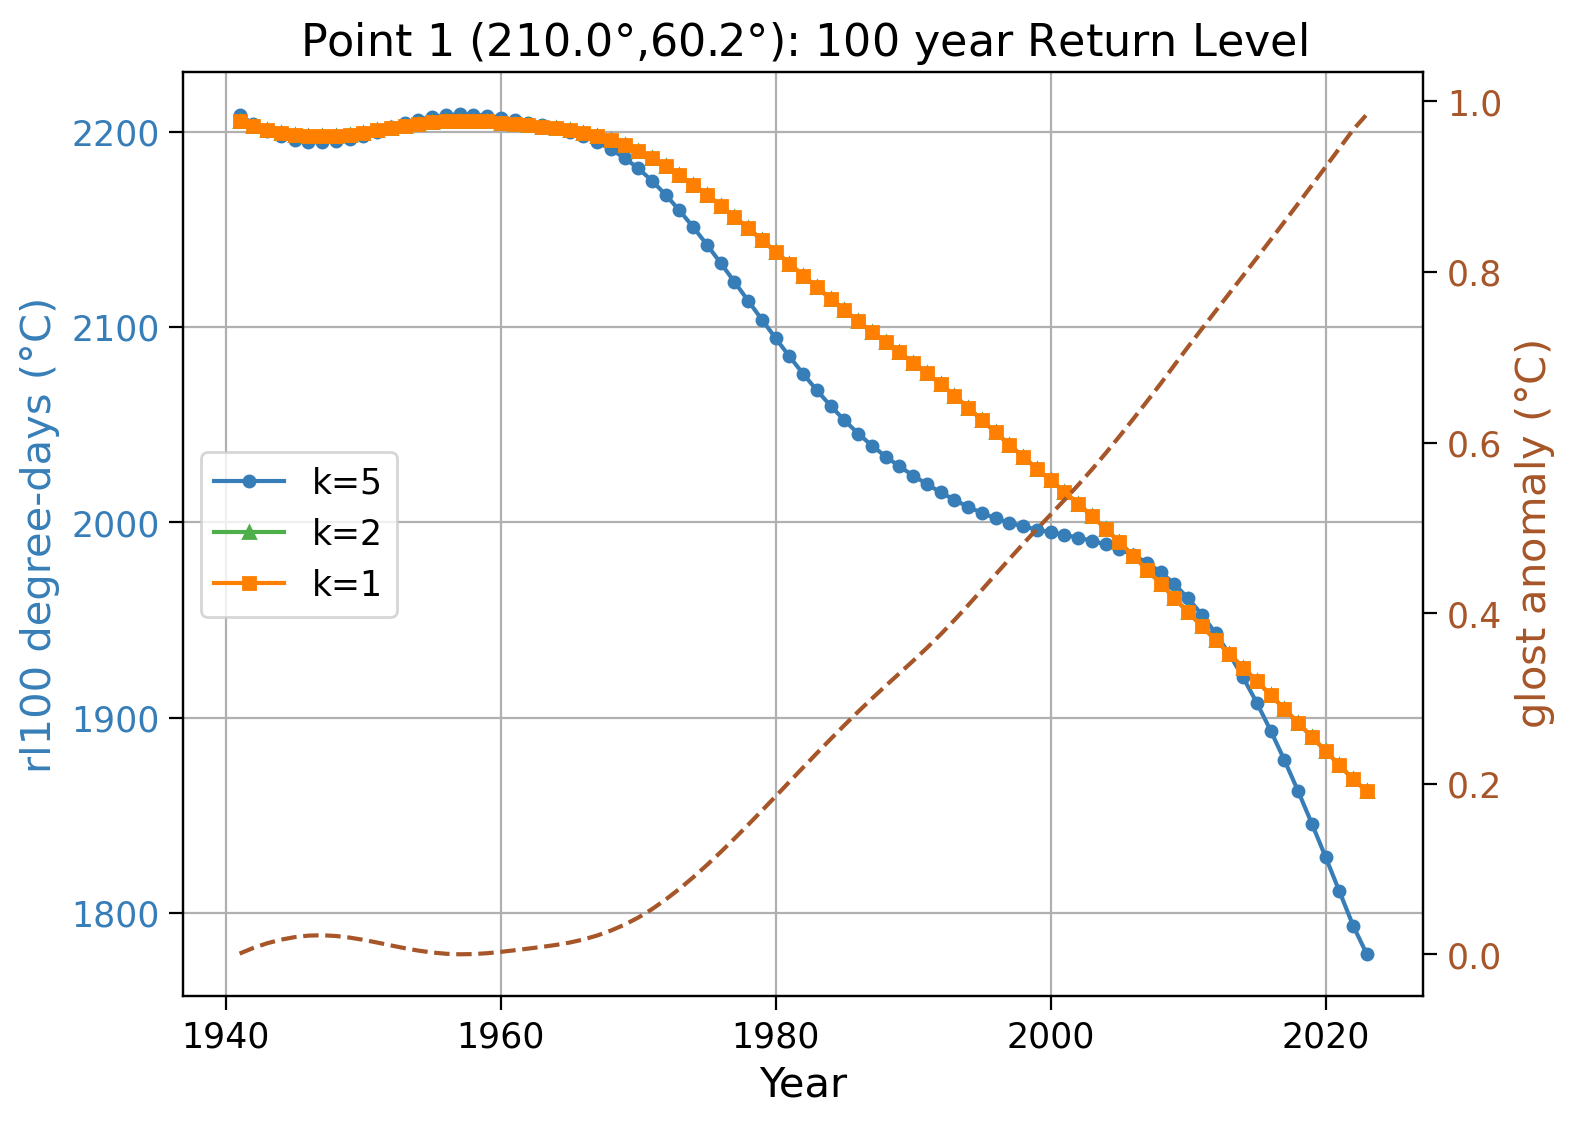

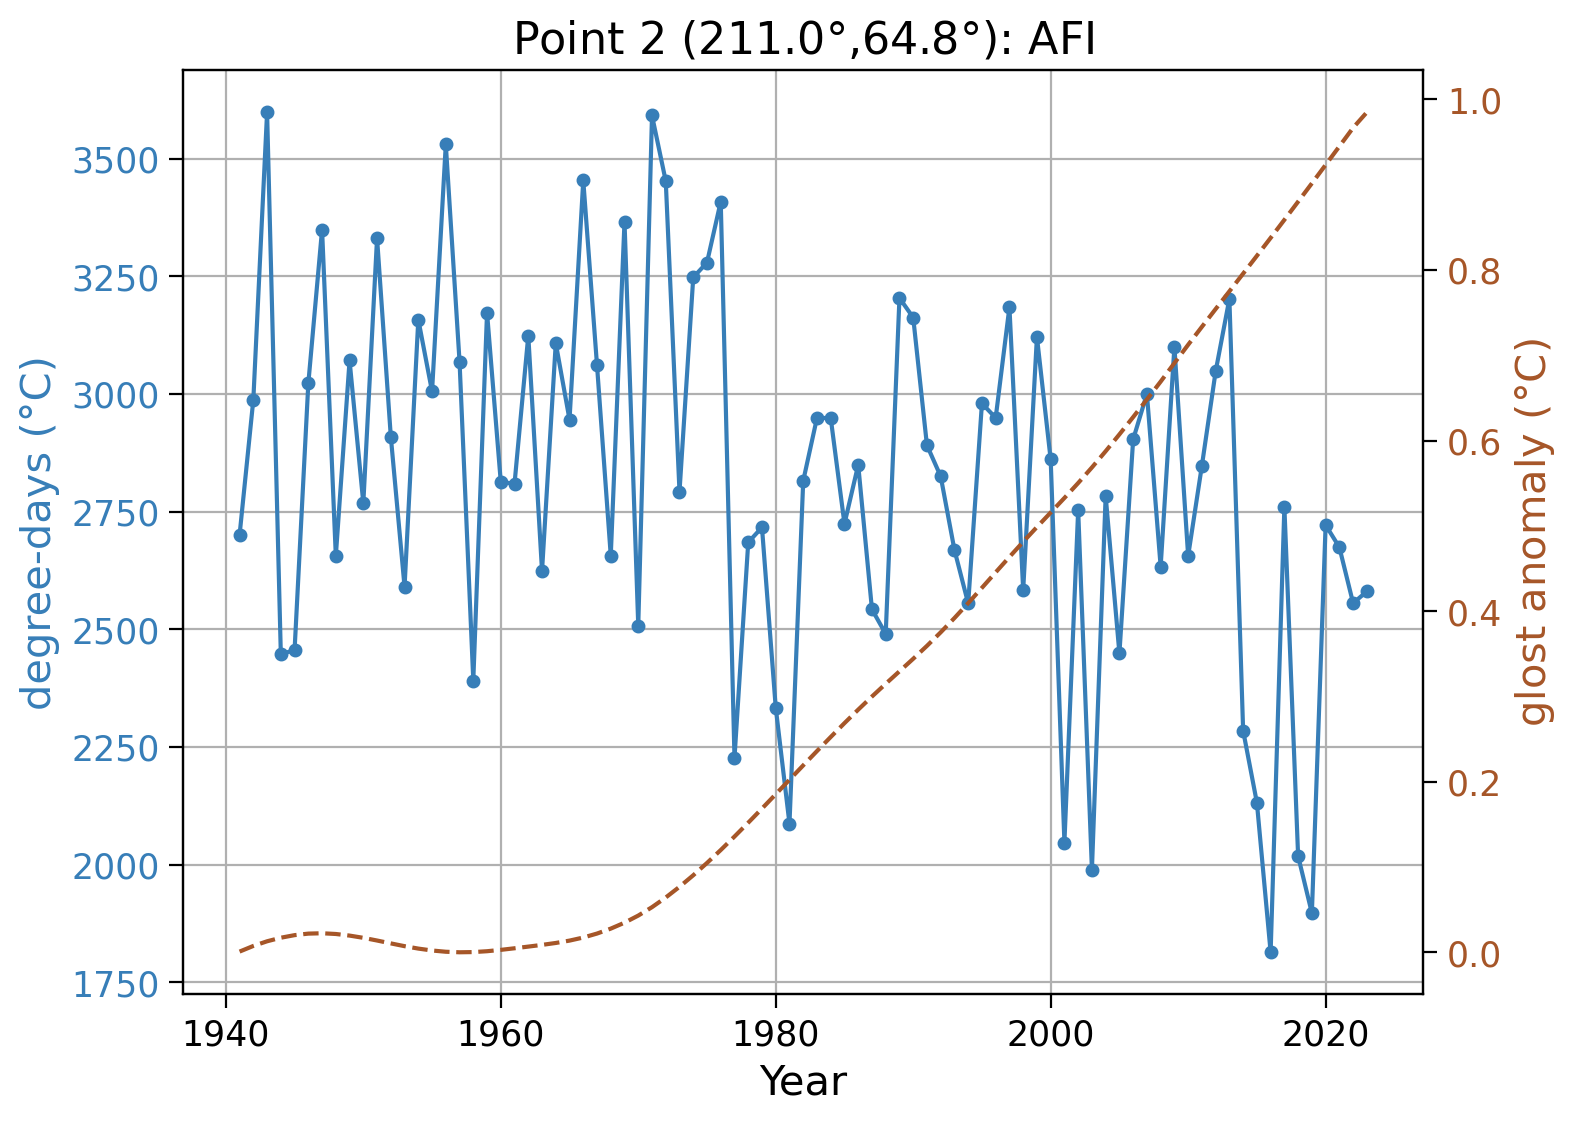

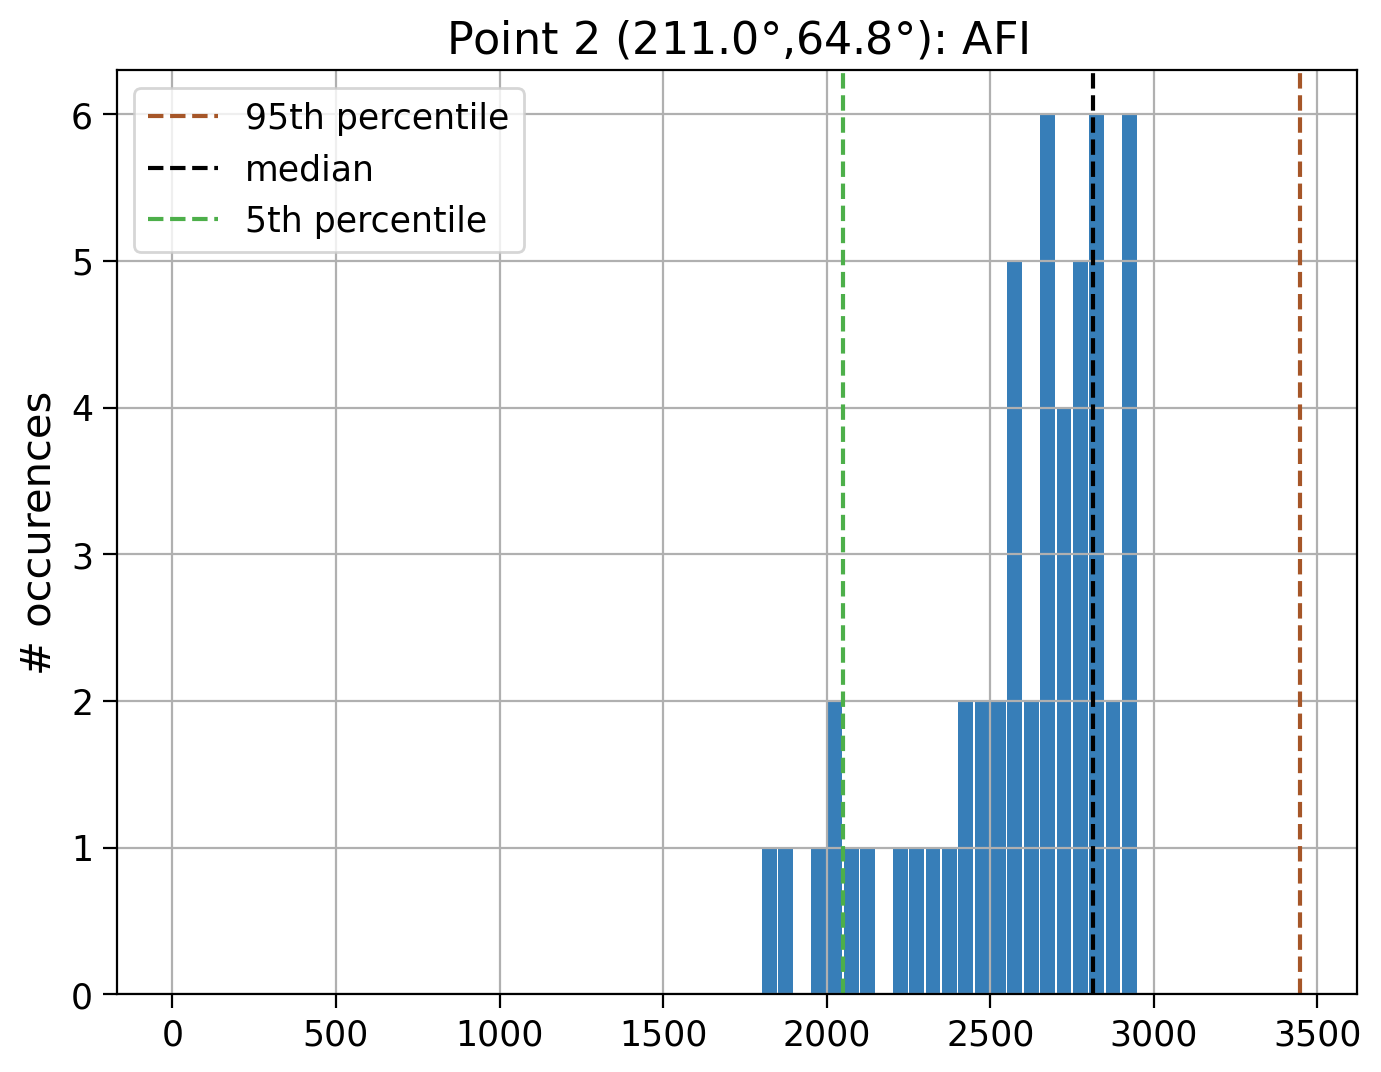

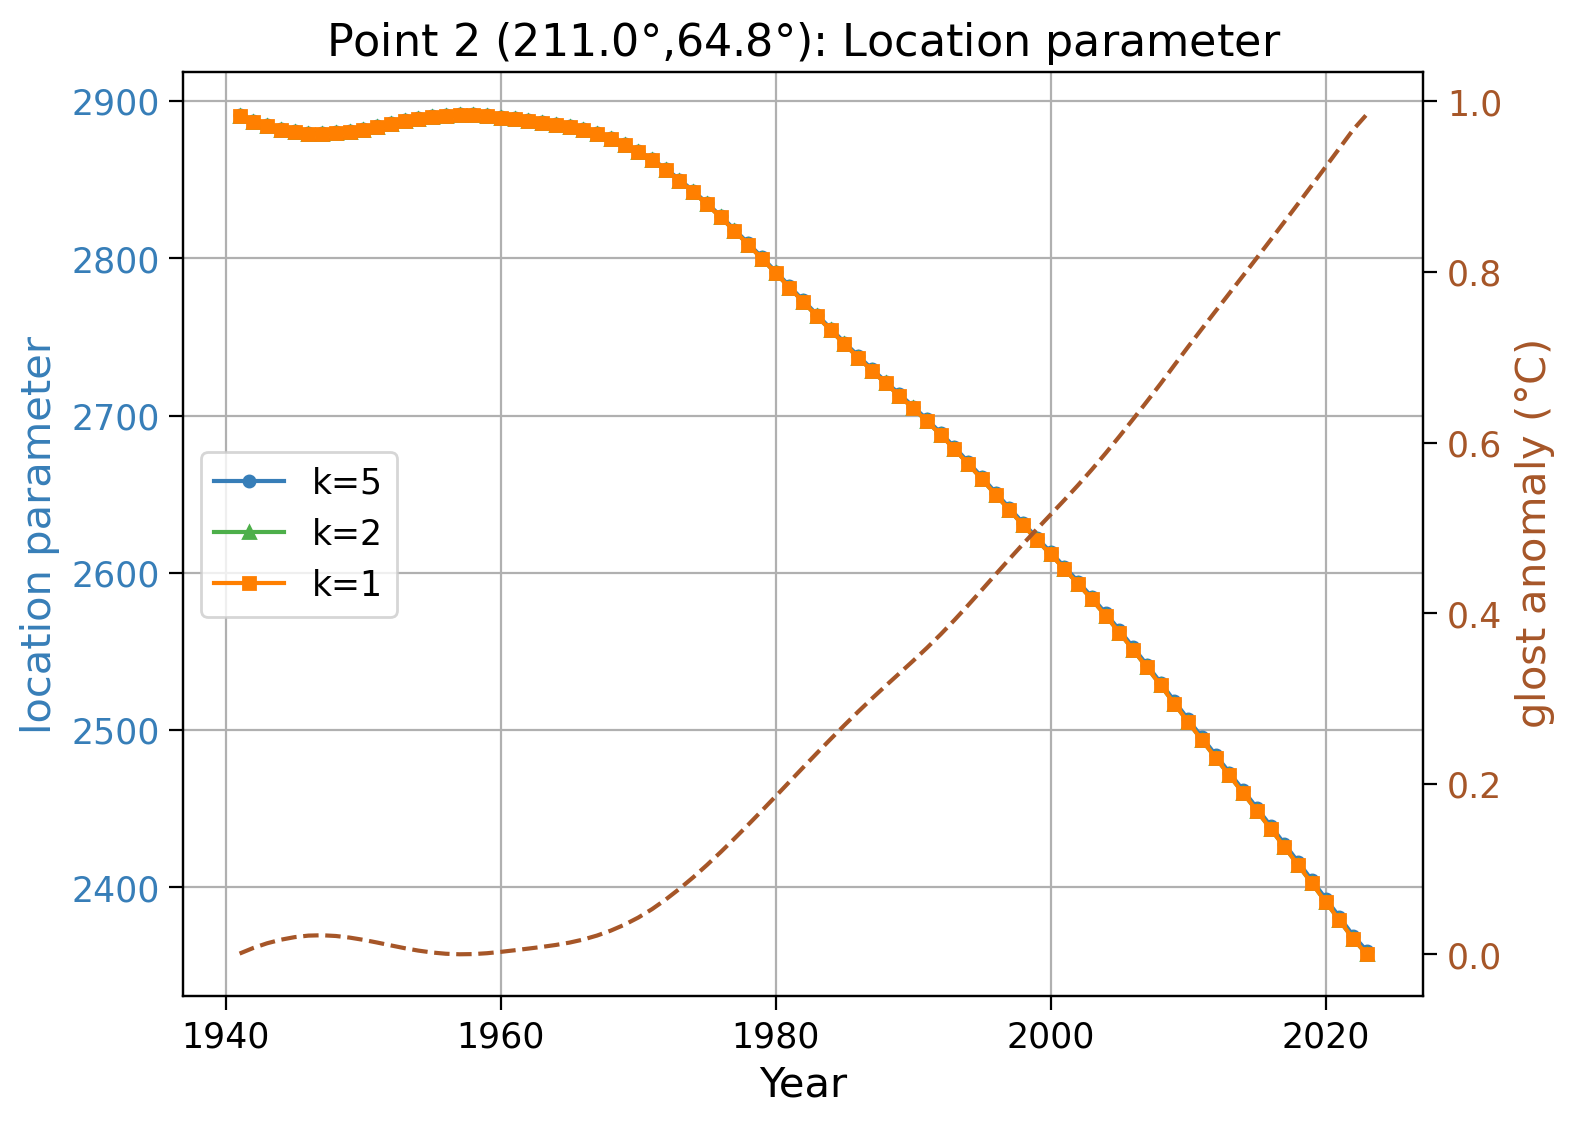

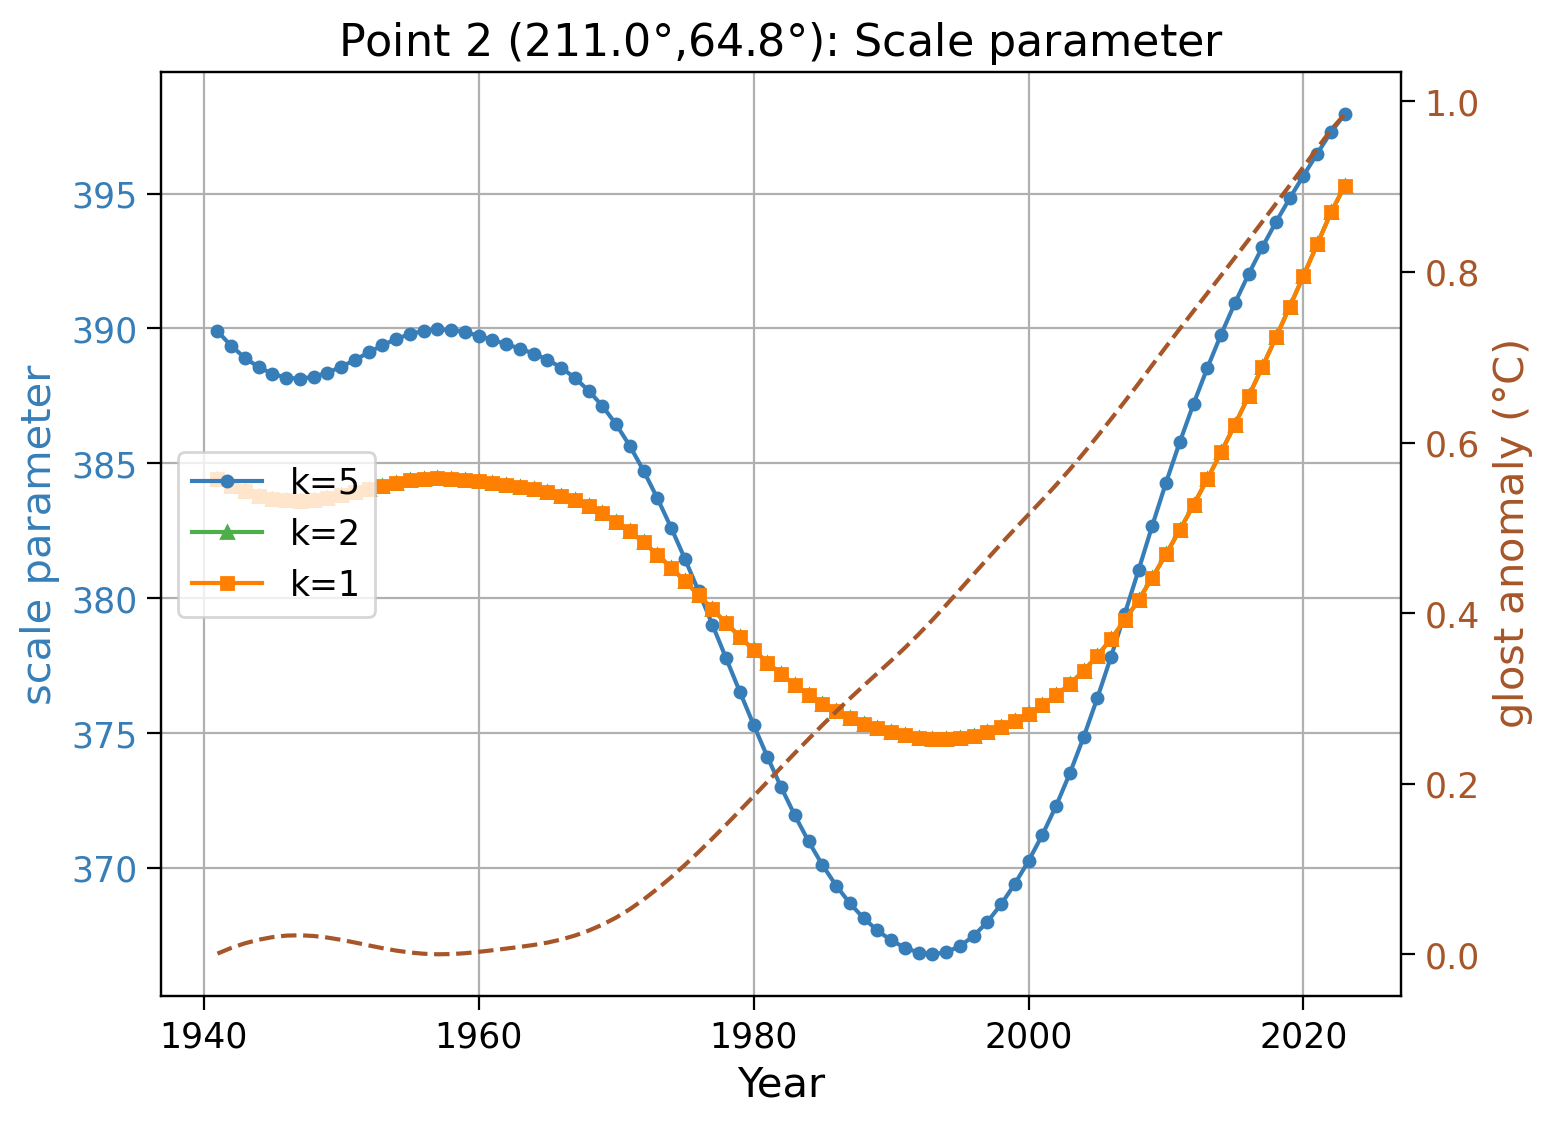

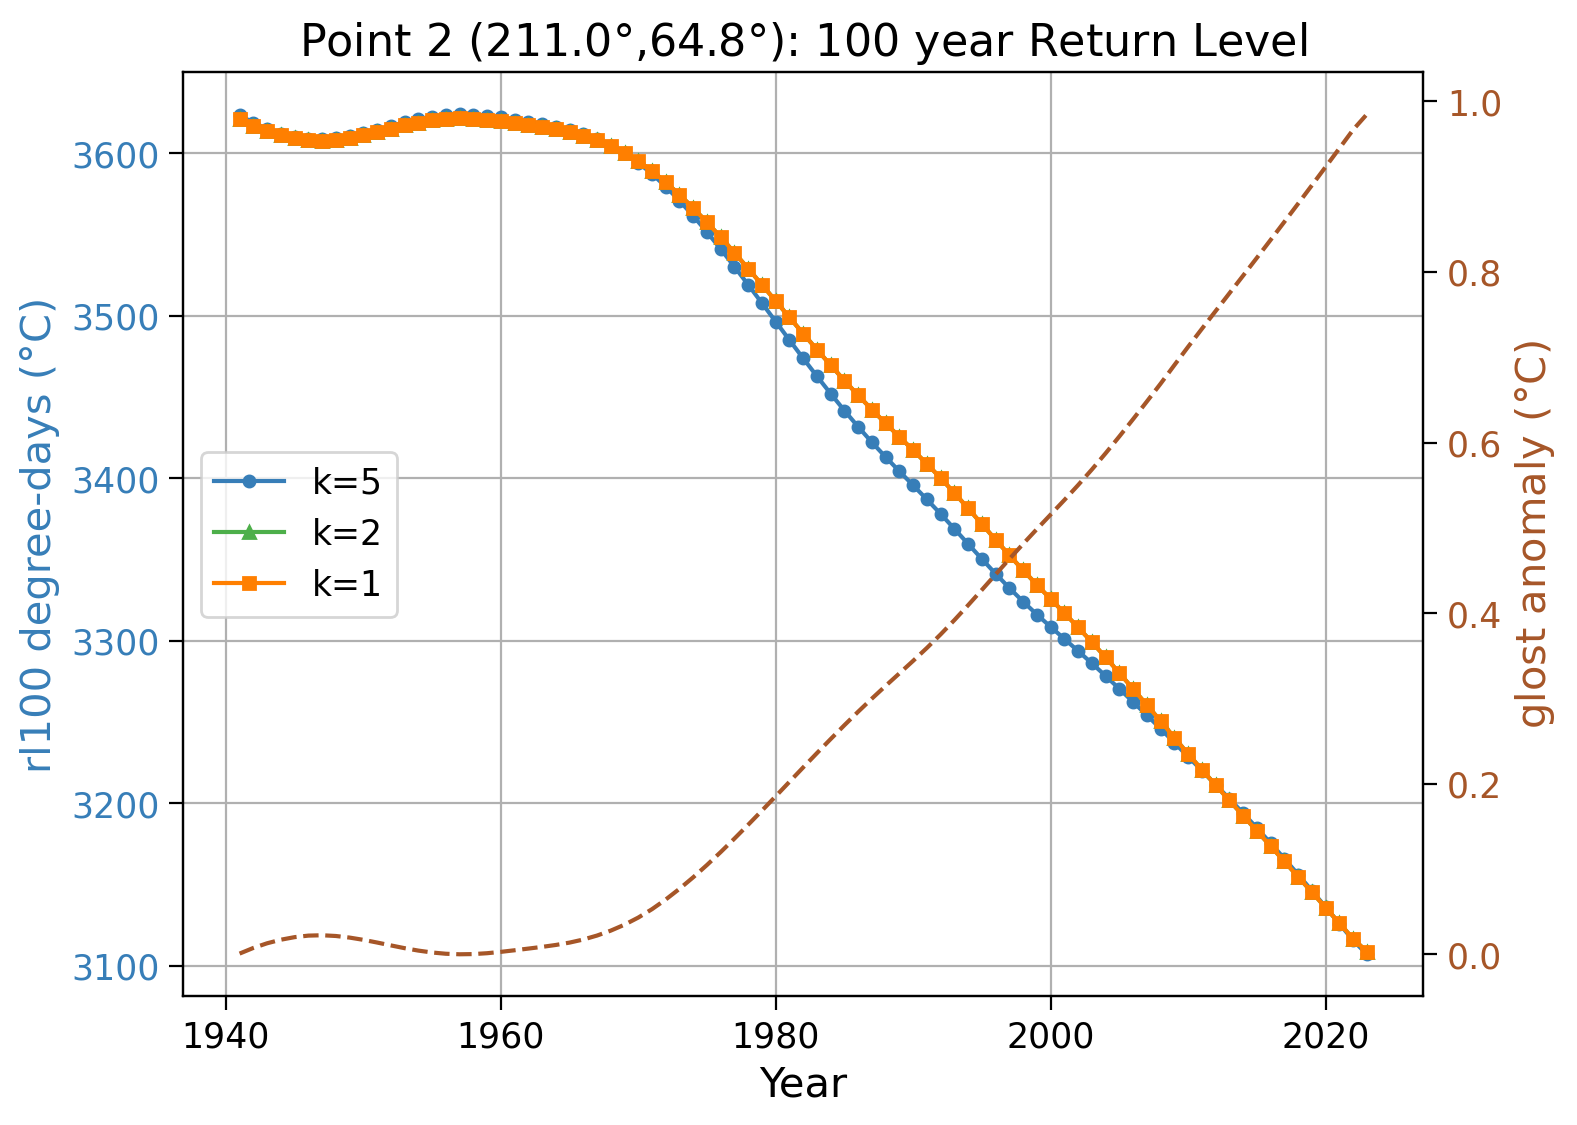

In [61]:
bins=np.arange(0,3000,50)

for ij in range(0,len(ptlon)):
  ilon=ptlon[ij]
  ilat=ptlat[ij]
  # Extract values for boxes
  dsij=dsa.sel(lon=ilon,lat=ilat).load()
  df = dsij.to_dataframe()
  df = df.reset_index()
  # Remove zeros and NAN 
  # Remove timeseries with less than 15 data (as in Bilotta et al.)
  # Save rows removed
  dfsave=df[(df['AFI'] <= 0.)|(df['AFI'].isna())]
  df = df[df['AFI'] > 0.]

  dfsave=pd.concat([dfsave, df.groupby(['lon', 'lat']).filter(lambda x: len(x) <= 49)])
  df=df.groupby(['lon', 'lat']).filter(lambda x: len(x) > 49)
  # Convert xarray to pandas DataFrame to R data.frame
  # You can now work with 'r_df' in R
  with (ro.default_converter + pandas2ri.converter).context():
    r_df = ro.conversion.get_conversion().py2rpy(df)
  globalenv['r_df'] = r_df

  # EVGAM model fitting  
  %R m_gev5 <- evgam(fmla_gev5, r_df, family = "gev")
  %R gev_pred5 <- predict(m_gev5, r_df, type = "response")
  %R gev_rl1005 <- predict(m_gev5, r_df, prob = 0.99)
  #
  %R m_gev2 <- evgam(fmla_gev2, r_df, family = "gev")
  %R gev_pred2 <- predict(m_gev2, r_df, type = "response")
  %R gev_rl1002 <- predict(m_gev2, r_df, prob = 0.99)
  #
  %R m_gev1 <- evgam(fmla_gev1, r_df, family = "gev")
  %R gev_pred1 <- predict(m_gev1, r_df, type = "response")
  %R gev_rl1001 <- predict(m_gev1, r_df, prob = 0.99)
  print('#############')
  print('#############')
  print(f'Point {ij+1}')
  print('#############')
  print('#############')

  print('******')
  print('k=5')
  print('******')
  %R plot(m_gev5)
  %R pp5<-summary(m_gev5)
  %R location_pvalue5 <- pp5[[2]][['location']][['Pr(>|t|)']]
  %R scale_pvalue5 <- pp5[[2]][['logscale']][['Pr(>|t|)']]
  %R print(pp5)
  %R -o gev_pred5,pp5,gev_rl1005,location_pvalue5,scale_pvalue5

  print('******')
  print('k=2')
  print('******')
  %R plot(m_gev2)
  %R pp2<-summary(m_gev2)
  %R location_pvalue2 <- pp2[[2]][['location']][['Pr(>|t|)']]
  %R scale_pvalue2 <- pp2[[2]][['logscale']][['Pr(>|t|)']]
  %R print(pp2)
  %R -o gev_pred2,pp2,gev_rl1002,location_pvalue2,scale_pvalue2

  print('******')
  print('k=1')
  print('******')
  %R plot(m_gev1)
  %R pp1<-summary(m_gev1)
  %R location_pvalue1 <- pp1[[2]][['location']][['Pr(>|t|)']]
  %R scale_pvalue1 <- pp1[[2]][['logscale']][['Pr(>|t|)']]
  %R print(pp1)
  %R -o gev_pred1,pp1,gev_rl1001,location_pvalue1,scale_pvalue1
  #####
  # PLOTS
  #####
  fig, ax1 = plt.subplots()
  ax2 = ax1.twinx()
  ax1.plot(np.arange(yearb,yeare+1,1),dsij['AFI'],color='#377eb8',marker='o',markersize=4)
  ax1.set_ylabel(f'{units}', color='#377eb8')
  ax1.tick_params(axis='y', labelcolor='#377eb8')
  ax1.set_xlabel('Year')
  ax1.grid()
  ax2.plot(np.arange(yearb,yeare+1,1),ann_glost,linestyle='--',color='#a65628',label='glost anomaly')
  ax2.set_ylabel('glost anomaly ($\degree$C)', color='#a65628')
  ax2.tick_params(axis='y', labelcolor='#a65628')
  ax1.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): AFI',fontsize=16)
  outfile=f'PLOTS/AFI_glost_timeseries_NS{itest}_pt{ij+1}.png'
  plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')
  ######  
  d1=histogram(dsij['AFI'], bins=bins, block_size=None)
  per90th=dsij['AFI'].quantile(0.95)
  per50th=dsij['AFI'].quantile(0.5)
  per10th=dsij['AFI'].quantile(0.05)
  fig, axs = plt.subplots()
  axs.bar((bins[1:]+bins[:-1])*0.5,d1.data,color='#377eb8',width=45)
  axs.axvline(per90th,color='#a65628', linewidth=1.5,linestyle='--', label="95th percentile" )
  axs.axvline(per50th,color='black',linewidth=1.5,linestyle='--', label="median")
  axs.axvline(per10th,color='#4daf4a',  linewidth=1.5,linestyle='--', label="5th percentile" )
  axs.set_ylabel('# occurences', color='k')
  axs.grid()
  axs.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): AFI',fontsize=16)
  plt.legend(loc='best')
  outfile=f'PLOTS/AFI_glost_histogram_NS{itest}_pt{ij+1}.png'
  plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')
  ######
  fig, ax1 = plt.subplots()
  ax2 = ax1.twinx()
  ax1.plot(np.arange(yearb,yeare+1,1),gev_pred5['location'],label='k=5',color='#377eb8',marker='o',markersize=4)
  ax1.plot(np.arange(yearb,yeare+1,1),gev_pred2['location'],label='k=2',color='#4daf4a',marker='^',markersize=4)
  ax1.plot(np.arange(yearb,yeare+1,1),gev_pred1['location'],label='k=1',color='#ff7f00',marker='s',markersize=4)
  ax1.set_ylabel(f'location parameter', color='#377eb8')
  ax1.tick_params(axis='y', labelcolor='#377eb8')
  ax2.plot(np.arange(yearb,yeare+1,1),ann_glost,linestyle='--',color='#a65628',label='glost anomaly')
  ax2.set_ylabel('glost anomaly ($\degree$C)', color='#a65628')
  ax2.tick_params(axis='y', labelcolor='#a65628')
  ax1.set_xlabel('Year')
  ax1.grid()
  ax1.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): Location parameter'\
    ,fontsize=16)
  ax1.legend(loc='center left')
  outfile=f'PLOTS/location_glost_timeseries_NS{itest}_pt{ij+1}.png'
  plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')
  ######
  fig, ax1 = plt.subplots()
  ax2 = ax1.twinx()
  ax2.plot(np.arange(yearb,yeare+1,1),ann_glost,linestyle='--',color='#a65628',label='glost anomaly')
  ax2.set_ylabel('glost anomaly ($\degree$C)', color='#a65628')
  ax2.tick_params(axis='y', labelcolor='#a65628')
  ax1.plot(np.arange(yearb,yeare+1,1),gev_pred5['scale'],label='k=5',color='#377eb8',marker='o',markersize=4)
  ax1.plot(np.arange(yearb,yeare+1,1),gev_pred2['scale'],label='k=2',color='#4daf4a',marker='^',markersize=4)
  ax1.plot(np.arange(yearb,yeare+1,1),gev_pred1['scale'],label='k=1',color='#ff7f00',marker='s',markersize=4)
  ax1.set_ylabel(f'scale parameter', color='#377eb8')
  ax1.tick_params(axis='y', labelcolor='#377eb8')
  ax1.set_xlabel('Year')
  ax1.grid()
  ax1.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): Scale parameter'\
    ,fontsize=16)
  ax1.legend(loc='center left')
  outfile=f'PLOTS/scale_glost_timeseries_NS{itest}_pt{ij+1}.png'
  plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')
  ######
  fig, ax1 = plt.subplots()
  ax2 = ax1.twinx()
  ax2.plot(np.arange(yearb,yeare+1,1),ann_glost,linestyle='--',color='#a65628',label='glost anomaly')
  ax2.set_ylabel('glost anomaly ($\degree$C)', color='#a65628')
  ax2.tick_params(axis='y', labelcolor='#a65628')
  ax1.plot(np.arange(yearb,yeare+1,1),gev_rl1005['q:0.99'],label='k=5',color='#377eb8',marker='o',markersize=4)
  ax1.plot(np.arange(yearb,yeare+1,1),gev_rl1002['q:0.99'],label='k=2',color='#4daf4a',marker='^',markersize=4)
  ax1.plot(np.arange(yearb,yeare+1,1),gev_rl1001['q:0.99'],label='k=1',color='#ff7f00',marker='s',markersize=4)
  ax1.set_ylabel(f'rl100 {units}', color='#377eb8')
  ax1.tick_params(axis='y', labelcolor='#377eb8')
  ax1.set_xlabel('Year')
  ax1.grid()
  ax1.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): 100 year Return Level'\
    ,fontsize=16)
  ax1.legend(loc='center left')  
  outfile=f'PLOTS/rl100_glost_timeseries_NS{itest}_pt{ij+1}.png'
  plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')